# ME5311 Project 1 — Spatio‑temporal data analysis

This notebook documents the **full data‑analysis workflow** used for ME5311 Project 1.  
The emphasis is on extracting structural and statistical information directly from the
2‑D spatio‑temporal vector field, in line with the four guiding questions of the
assignment (dominant spatial structures, spectral scales, externally imposed wavenumber,
and symmetry/anisotropy).

The workflow combines:

- Pre‑processing, basic visual inspection, and global statistics of the velocity field.
- Low‑rank SVD of the fluctuation field, including singular spectrum and leading modes.
- Spatial and temporal Fourier analysis (2‑D spectrum, radial spectrum, temporal PSD).
- Symmetry and anisotropy diagnostics based on both spectra and SVD modes.

All figures used in the report (including the final composite figure) are generated by
this workflow and saved into the `figures/` directory.

[data] opened vector_64.npy: shape=(15000, 64, 64, 2), dtype=float64, size=0.98 GB
[data] data_matrix: (8192, 15000)
[data] vorticity field: (15000, 64, 64)
[data] divergence field: (15000, 64, 64)
[viz] Saved → C:\Users\10649\Desktop\ME5311\Spatiotemporal-Data-Analysis\figures\None.png
[svd] start compact SVD factorisation
[svd] done: U=(8192, 8192), S=(8192,), Vt=(8192, 15000)
[svd] modes for 95% energy: 32, 99% energy: 72
[viz] Saved → C:\Users\10649\Desktop\ME5311\Spatiotemporal-Data-Analysis\figures\svd_singular_values.png
[viz] Saved → C:\Users\10649\Desktop\ME5311\Spatiotemporal-Data-Analysis\figures\svd_reconstruction_error.png
[viz] Saved → C:\Users\10649\Desktop\ME5311\Spatiotemporal-Data-Analysis\figures\svd_mode_energy_bars.png
[viz] Saved → C:\Users\10649\Desktop\ME5311\Spatiotemporal-Data-Analysis\figures\svd_spatial_modes.png
[viz] Saved → C:\Users\10649\Desktop\ME5311\Spatiotemporal-Data-Analysis\figures\svd_temporal_coeff.png
[viz] Saved → C:\Users\10649\Desktop\ME5311

{'energy_ratio': np.float64(0.6257376452582807),
 'mirror_err_x': np.float64(1.9153112112923631),
 'mirror_err_y': np.float64(1.9470853575319735),
 'rotation_err': np.float64(0.3637610302898759),
 'anisotropy_ratio': array([0.99999995, 0.51980926, 1.5672019 , 0.72136672, 1.34963299,
        0.39211578, 0.38633312, 0.40351395, 0.56062928, 0.56319012,
        0.64739606, 0.67796635, 0.77247297, 0.81297252, 0.8241929 ,
        0.90639488, 0.81491555, 0.13707716, 0.84815532, 1.30395013,
        0.07421333, 0.33185227, 0.52198564, 0.08975513, 0.24326643,
        0.96674267, 0.56575644, 0.2108811 , 0.24764073, 0.38199043,
        1.1895157 , 0.31052318, 0.48179641]),
 'mode_symmetry': [{'mode': 1,
   'ux_corr_x': 0.8015746866447729,
   'ux_corr_y': -0.5041121680523662,
   'uy_corr_x': 0.9946345352863596,
   'uy_corr_y': -0.7152040266915599},
  {'mode': 2,
   'ux_corr_x': -0.009515851634065398,
   'ux_corr_y': 0.6974814508257663,
   'uy_corr_x': 0.9926402237229086,
   'uy_corr_y': 0.736689646

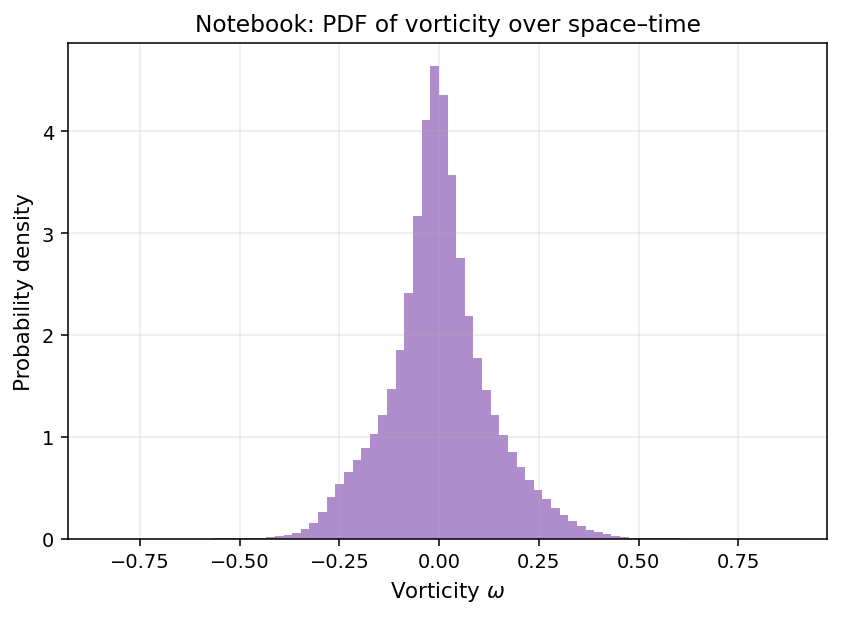

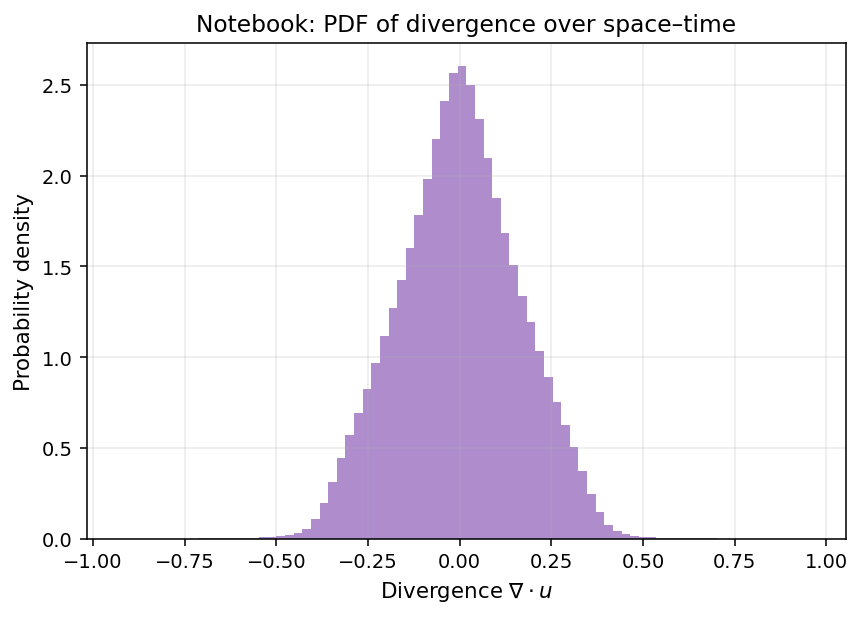

In [1]:
# Optional: re-run the full analysis pipeline from within the notebook
# to regenerate all figures, including the additional diagnostics.

from pathlib import Path
import sys

# In a Jupyter notebook, __file__ is not defined; use ".." as project root.
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import data_loader as dl
from src import svd_analysis as svd
from src import spectral_analysis as spectral
from src import symmetry_analysis as symmetry
from src import visualization as viz

import numpy as np

# Load and preprocess the dataset (basic fields and diagnostics)
bundle = dl.load_and_preprocess()

# Step 0: basic figures + new global statistics (displayed only inside the notebook)
_ = viz.plot_kinetic_energy_timeseries(
    bundle["raw"],
    dt=dl.DT,
    save_name=None,
)
_ = viz.plot_scalar_histogram(
    bundle["vorticity"],
    bins=80,
    title="Notebook: PDF of vorticity over space–time",
    xlabel="Vorticity $\\omega$",
    save_name=None,
)
_ = viz.plot_scalar_histogram(
    bundle["divergence"],
    bins=80,
    title="Notebook: PDF of divergence over space–time",
    xlabel="Divergence $\\nabla\\cdot u$",
    save_name=None,
)

# Step 1: SVD analysis with extended diagnostics
svd_results = svd.run(bundle["data_matrix"], dt=dl.DT, ny=dl.NY, nx=dl.NX, n_modes=6)

# Step 2: spectral analysis with compensated/cumulative spectra
spectral_results = spectral.run(bundle["fluctuation"], dt=dl.DT)

# Step 3: symmetry and anisotropy overview, including anisotropy ratio curve
leading_modes = svd.extract_spatial_modes(svd_results["U"], n_modes=6)
symmetry_results = symmetry.run(
    bundle["fluctuation"],
    spectral_results["psd_total_2d"],
    svd_modes=leading_modes,
)

symmetry_results

# ME5311 Project 1 — Exploratory Analysis of a 2D Vector Time Series

**Notebook owner**: Tan Kailai (e1554333@u.nus.edu) · **Module**: NUS ME5311

---

This notebook documents one exploratory workflow for the 2D
spatiotemporal vector field provided in ME5311 Project 1. The emphasis
is on characterising structures and statistics already present in the
simulation output, rather than constructing predictive models.

| Stage | Main task | Relation to project questions |
|-------|-----------|-------------------------------|
| Stage 0 | Load data, separate slowly varying background and fluctuations, compute vorticity/divergence | Preprocessing and basic inspection |
| Stage 1 | Low‑rank SVD/PCA of the fluctuation field: singular spectrum, leading spatial patterns, modal time series | Q1: dominant spatial structures |
| Stage 2 | Fourier analysis in space and time: 2D PSD, radial spectrum, temporal PSD | Q2: energy across scales; Q3: temporal signatures |
| Stage 3 | Symmetry and anisotropy diagnostics | Q4: symmetry & anisotropy |

In [2]:
%matplotlib inline

import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Plot style and output folder (loosely aligned with src.visualization,
# but intentionally with a slightly different default colormap)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "image.cmap": "cividis",
})
fig_out_dir = project_root / "figures"
fig_out_dir.mkdir(exist_ok=True)

from src import data_loader as dl
print("Notebook environment initialised.")

Notebook environment initialised.


---
## Step 0: Data loading and derived fields

We read `vector_64.npy` and build a small set of derived quantities used later:

- **Background field** $\bar{\mathbf{u}}(x,y)$ — temporal average over all snapshots.
- **Perturbation** $\mathbf{u}' = \mathbf{u} - \bar{\mathbf{u}}$ — deviation from that mean.
- **Vorticity** $\omega = \partial_x u_y - \partial_y u_x$ and **divergence** $\nabla\cdot\mathbf{u}$, via centred finite differences on the periodic grid.

In [3]:
# Single high‑level entry point returning a bundle of arrays
bundle = dl.load_and_preprocess()
raw_field   = bundle["raw"]            # (nt, ny, nx, 2)
mean_field  = bundle["mean_field"]     # (ny, nx, 2)
fluct_field = bundle["fluctuation"]    # (nt, ny, nx, 2)
data_matrix = bundle["data_matrix"]    # (8192, 15000)
vorticity   = bundle["vorticity"]      # (nt, ny, nx)
divergence  = bundle["divergence"]     # (nt, ny, nx)

# Quick sanity check
print(f"Raw field shape: {raw_field.shape}")
print(f"Raw field dtype: {raw_field.dtype}")
print(f"Value range: [{raw_field.min():.4f}, {raw_field.max():.4f}]")
print(f"ux mean: {raw_field[...,0].mean():.6f}, std: {raw_field[...,0].std():.4f}")
print(f"uy mean: {raw_field[...,1].mean():.6f}, std: {raw_field[...,1].std():.4f}")

# Aliases for downstream cells (keep names used later in the notebook)
snapshots = raw_field
u_mean = mean_field
u_prime = fluct_field
X_mat = data_matrix
omega = vorticity
div_u = divergence

raw = raw_field
fluctuation = fluct_field
FIG_DIR = fig_out_dir

[data] opened vector_64.npy: shape=(15000, 64, 64, 2), dtype=float64, size=0.98 GB
[data] data_matrix: (8192, 15000)
[data] vorticity field: (15000, 64, 64)
[data] divergence field: (15000, 64, 64)
Raw field shape: (15000, 64, 64, 2)
Raw field dtype: float64
Value range: [-3.3726, 3.1009]
ux mean: -0.001017, std: 0.7072
uy mean: -0.001199, std: 0.9311


### 0.1 Background (time-averaged) field

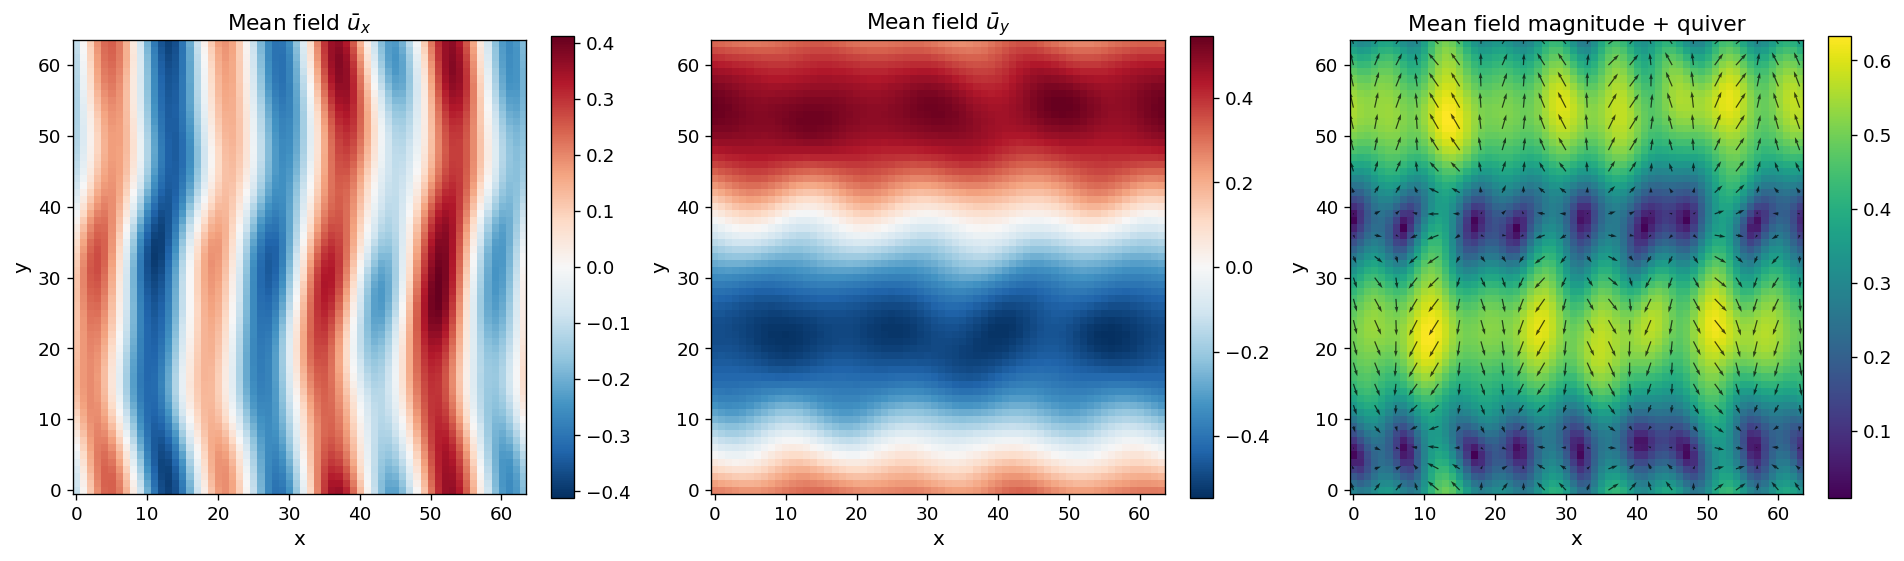

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ux component
ux_mean = u_mean[..., 0]
im0 = axes[0].imshow(ux_mean, origin='lower', cmap='RdBu_r',
                      vmin=-np.abs(ux_mean).max(), vmax=np.abs(ux_mean).max())
axes[0].set_title('Mean field $\\bar{u}_x$')
fig.colorbar(im0, ax=axes[0], fraction=0.046)

# uy component
uy_mean = u_mean[..., 1]
im1 = axes[1].imshow(uy_mean, origin='lower', cmap='RdBu_r',
                      vmin=-np.abs(uy_mean).max(), vmax=np.abs(uy_mean).max())
axes[1].set_title('Mean field $\\bar{u}_y$')
fig.colorbar(im1, ax=axes[1], fraction=0.046)

# Velocity magnitude + quiver
mag = np.sqrt(ux_mean**2 + uy_mean**2)
im2 = axes[2].imshow(mag, origin='lower', cmap='viridis')
step = 3
Y, X = np.mgrid[0:64, 0:64]
axes[2].quiver(X[::step, ::step], Y[::step, ::step],
               ux_mean[::step, ::step], uy_mean[::step, ::step],
               color='k', alpha=0.7)
axes[2].set_title('Mean field magnitude + quiver')
fig.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_aspect('equal')
fig.tight_layout()
fig.savefig(fig_out_dir / 'step0_mean_field.png')
plt.show()

#### 📊 How to Interpret This Figure

| Item | Explanation |
|------|-------------|
| **Figure meaning** | Time-averaged vector field over 15000 time steps. Left: $u_x$ component, middle: $u_y$ component, right: velocity magnitude + arrow field |
| **How to read** | Red/blue indicates positive/negative values; arrow direction and length represent local flow direction and speed magnitude |
| **Good signal** | If mean field exhibits **obvious spatial periodicity**, external forcing leaves clear imprints on average |
| **Bad signal** | If mean field is near zero (all blue), mean state is symmetric, forcing manifests mainly in fluctuations |
| **Key conclusion** | Check for repeated streaks/vortex structures; estimate spatial period (grid points per repetition) |

### 0.2 Snapshots at Different Times

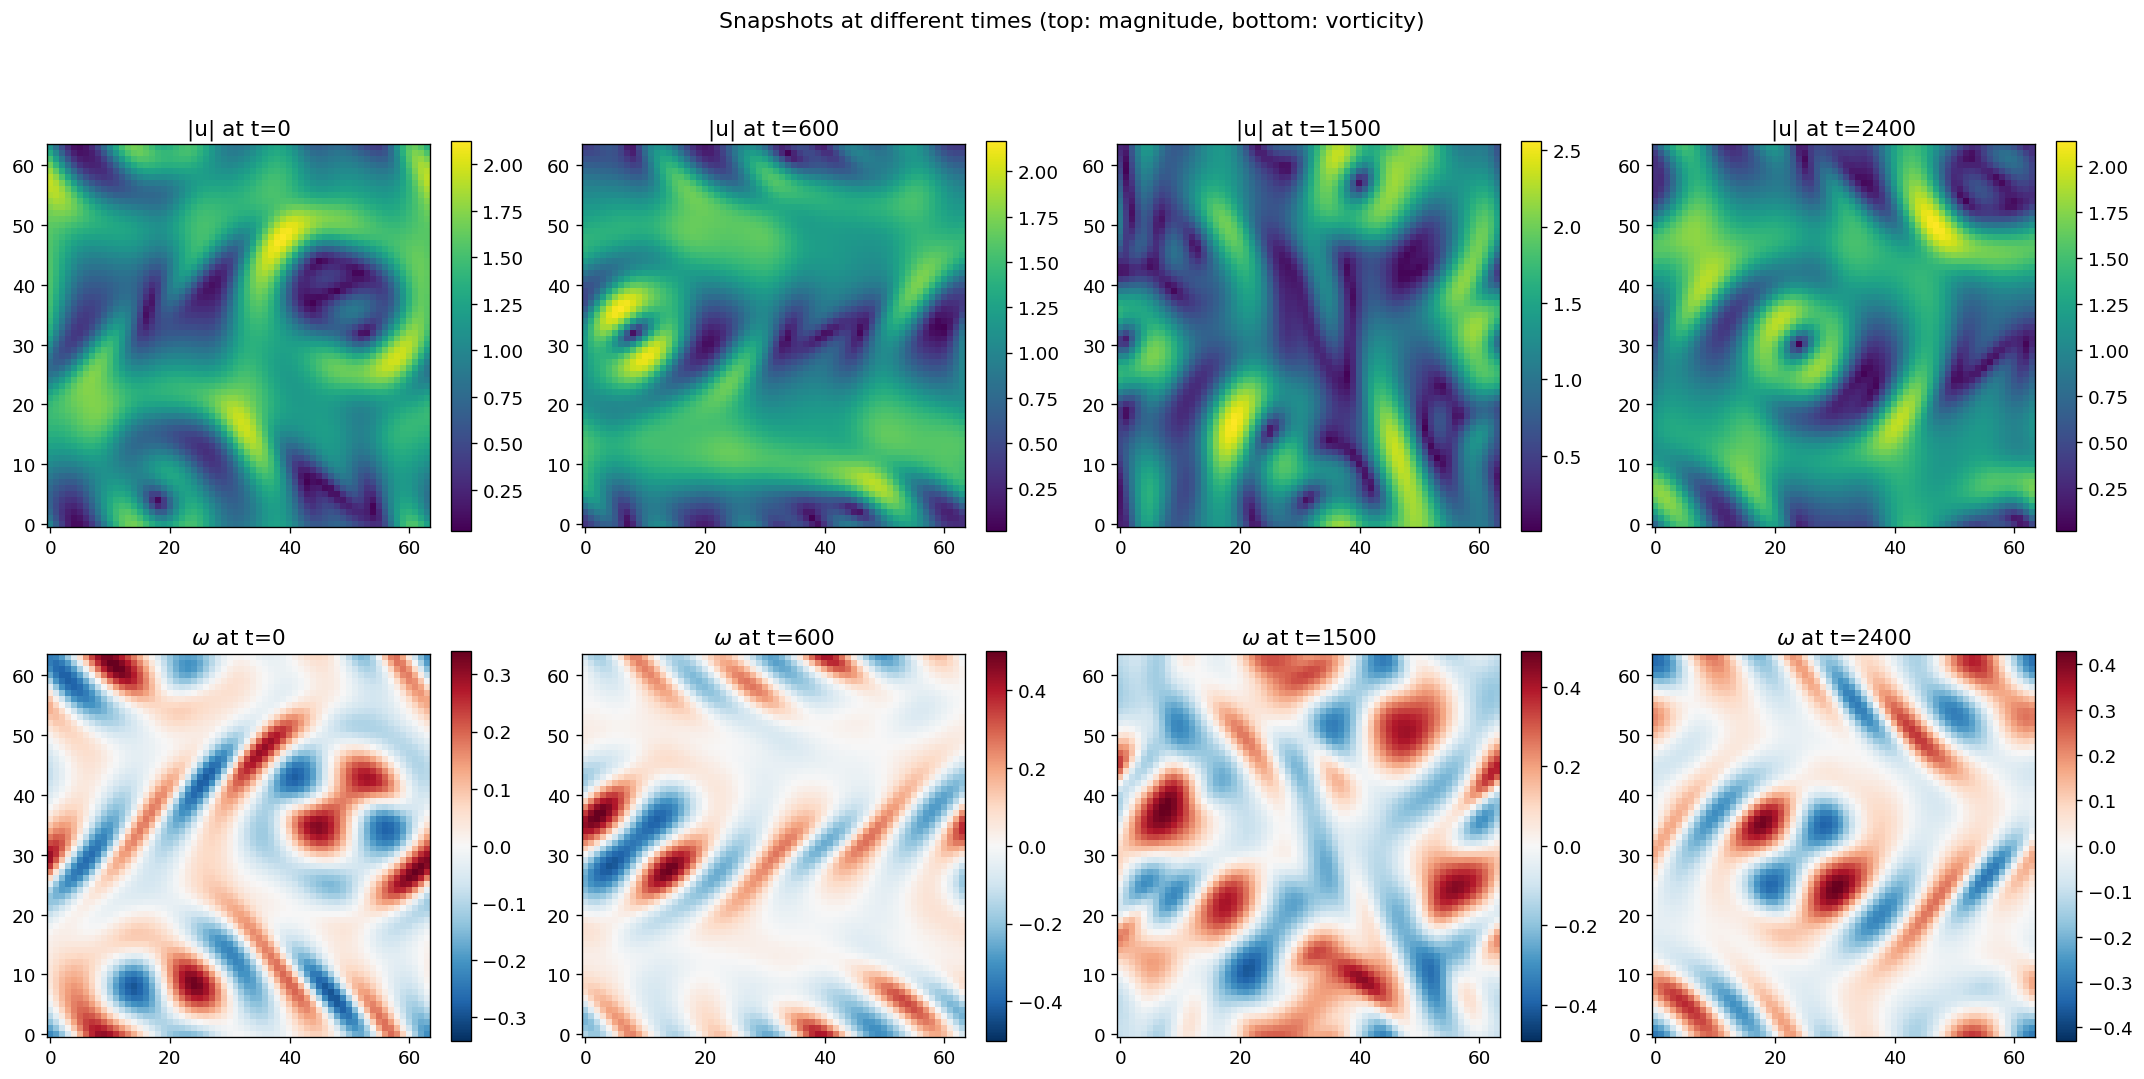

In [5]:
time_indices = [0, 3000, 7500, 12000]  # Different time steps
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for col, t_idx in enumerate(time_indices):
    t_val = t_idx * dl.DT
    snap = raw[t_idx]
    mag = np.sqrt(snap[...,0]**2 + snap[...,1]**2)

    # Top row: velocity magnitude
    im = axes[0, col].imshow(mag, origin='lower', cmap='viridis')
    axes[0, col].set_title(f'|u| at t={t_val:.0f}')
    fig.colorbar(im, ax=axes[0, col], fraction=0.046)

    # Bottom row: vorticity
    im = axes[1, col].imshow(vorticity[t_idx], origin='lower', cmap='RdBu_r',
                              vmin=-np.abs(vorticity[t_idx]).max(),
                              vmax=np.abs(vorticity[t_idx]).max())
    axes[1, col].set_title(f'$\\omega$ at t={t_val:.0f}')
    fig.colorbar(im, ax=axes[1, col], fraction=0.046)

for ax in axes.flat:
    ax.set_aspect('equal')
fig.suptitle('Snapshots at different times (top: magnitude, bottom: vorticity)', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'step0_snapshots.png')
plt.show()

#### 📊 How to Interpret This Figure

| Item | Explanation |
|------|-------------|
| **Figure meaning** | 4 snapshots of velocity magnitude (top row) and vorticity field (bottom row) at different times, showing temporal evolution |
| **How to read** | Top: brighter colors = higher speeds; Bottom: red/blue = positive/negative vorticity (counterclockwise/clockwise rotation) |
| **Good signal** | Patterns change over time but maintain similar spatial scales → system has a **characteristic length scale** |
| **Key conclusion** | Check for obvious spatial periodicity and similarity between different time instants |

### 0.3 Divergence Check (Is Flow Approximately Incompressible?)

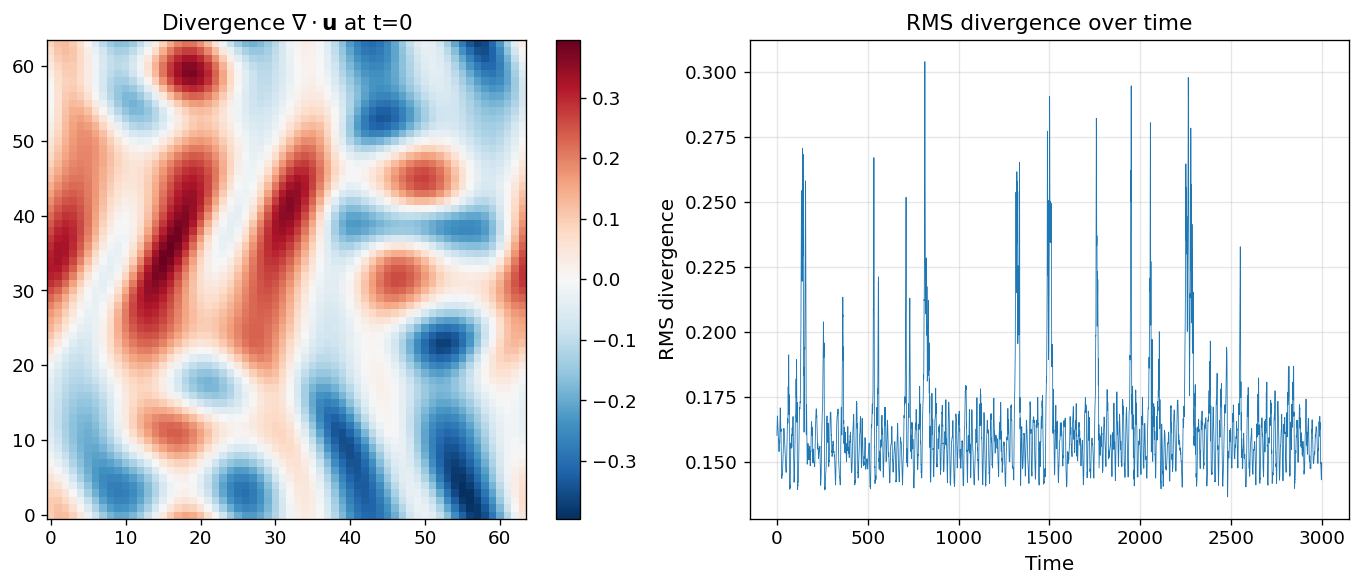

Global divergence RMS: 0.164251
Global velocity RMS: 0.826743
Divergence/velocity ratio: 0.198673


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Divergence snapshot
im = axes[0].imshow(divergence[0], origin='lower', cmap='RdBu_r',
                     vmin=-np.abs(divergence[0]).max(),
                     vmax=np.abs(divergence[0]).max())
axes[0].set_title('Divergence $\\nabla \\cdot \\mathbf{u}$ at t=0')
axes[0].set_aspect('equal')
fig.colorbar(im, ax=axes[0], fraction=0.046)

# Divergence statistics
div_rms = np.sqrt(np.mean(divergence**2, axis=(1, 2)))
axes[1].plot(np.arange(dl.NT) * dl.DT, div_rms, lw=0.5)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('RMS divergence')
axes[1].set_title('RMS divergence over time')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / 'step0_divergence.png')
plt.show()
print(f"Global divergence RMS: {np.sqrt(np.mean(divergence**2)):.6f}")
print(f"Global velocity RMS: {np.sqrt(np.mean(raw**2)):.6f}")
print(f"Divergence/velocity ratio: {np.sqrt(np.mean(divergence**2)) / np.sqrt(np.mean(raw**2)):.6f}")

#### 📊 How to Interpret This Figure

| Item | Explanation |
|------|-------------|
| **Figure meaning** | Left: divergence field at t=0; Right: RMS divergence over time |
| **How to read** | $\nabla \cdot \mathbf{u}$ closer to zero → flow closer to **incompressible** (like Navier-Stokes) |
| **Good signal** | Divergence/velocity ratio ≪ 1 (e.g., < 0.01) → approximately incompressible |
| **Bad signal** | Ratio ≈ 1 → flow has obvious compressibility, analysis must consider this |
| **Key conclusion** | Determine if system is incompressible flow, which affects subsequent physical interpretation |

---
## Stage 1: Low‑rank representation via SVD (Q1: dominant structures)

We view the fluctuation snapshots as columns of a large matrix
$A \in \mathbb{R}^{8192 \times 15000}$ and compute its compact SVD

$$A = U \Sigma V^T.$$

- **$U$**: left singular vectors — spatial patterns (basis functions).
- **$\Sigma$**: singular values — relative contribution of each mode.
- **$V^T$**: right singular vectors — time evolution (coefficients) of each mode.

In [7]:
# Compact SVD (min(8192, 15000) singular values)
print("Running SVD (this may take 1–2 minutes)…")
U, sigma, Vt = np.linalg.svd(X_mat, full_matrices=False)
print(f"SVD done: U={U.shape}, sigma={sigma.shape}, Vt={Vt.shape}")

# Energy statistics
energy = sigma**2
cum_energy = np.cumsum(energy) / energy.sum()
n95 = int(np.searchsorted(cum_energy, 0.95)) + 1
n99 = int(np.searchsorted(cum_energy, 0.99)) + 1
print(f"Modes needed to reach 95% energy: {n95}")
print(f"Modes needed to reach 99% energy: {n99}")

Running SVD (this may take 1–2 minutes)…
SVD done: U=(8192, 8192), sigma=(8192,), Vt=(8192, 15000)
Modes needed to reach 95% energy: 32
Modes needed to reach 99% energy: 72


### 1.1 Singular Value Spectrum and Cumulative Energy

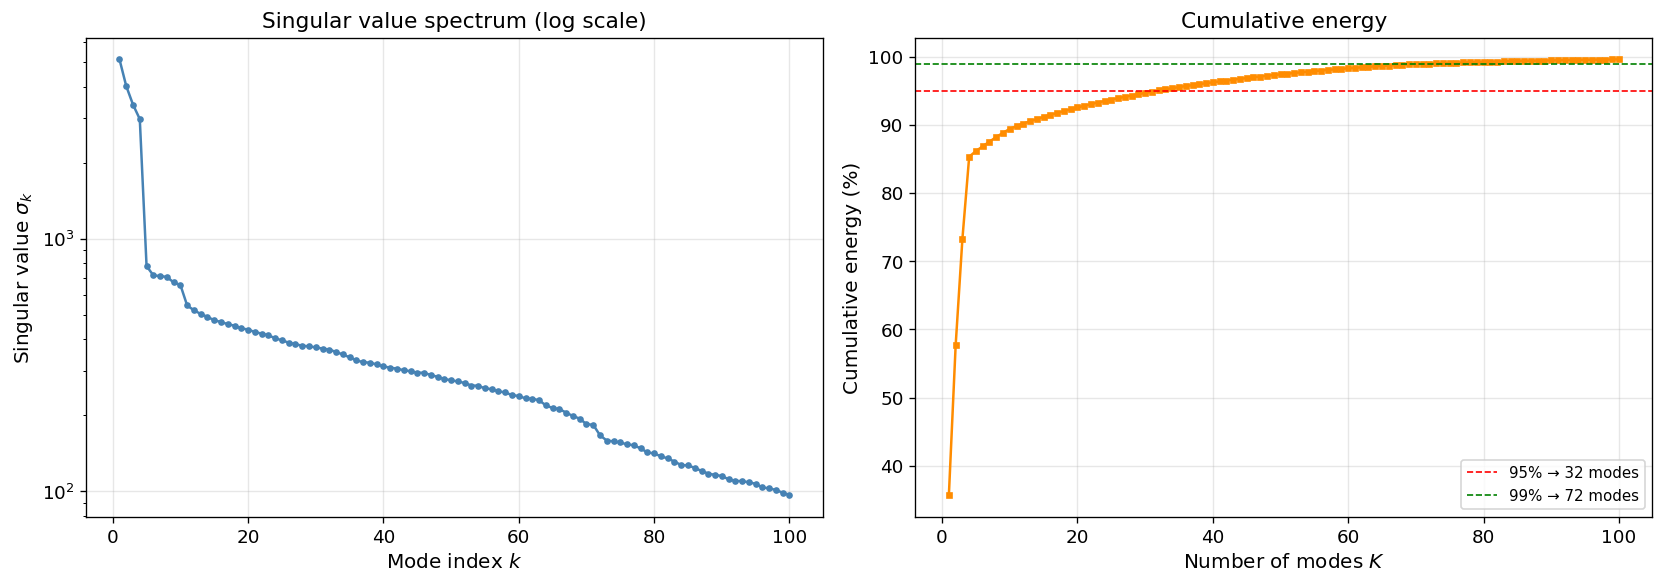


Energy fractions of first 10 modes:
  Mode 1: σ=5131.64, fraction=35.72%, cumulative=35.72%
  Mode 2: σ=4021.69, fraction=21.94%, cumulative=57.66%
  Mode 3: σ=3396.16, fraction=15.65%, cumulative=73.31%
  Mode 4: σ=2977.92, fraction=12.03%, cumulative=85.34%
  Mode 5: σ=780.29, fraction=0.83%, cumulative=86.17%
  Mode 6: σ=716.78, fraction=0.70%, cumulative=86.86%
  Mode 7: σ=711.60, fraction=0.69%, cumulative=87.55%
  Mode 8: σ=706.80, fraction=0.68%, cumulative=88.23%
  Mode 9: σ=671.85, fraction=0.61%, cumulative=88.84%
  Mode 10: σ=656.71, fraction=0.59%, cumulative=89.43%


In [8]:
n_show = min(100, len(sigma))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: singular values (log scale)
axes[0].semilogy(np.arange(1, n_show+1), sigma[:n_show], 'o-', ms=3, color='steelblue')
axes[0].set_xlabel('Mode index $k$')
axes[0].set_ylabel('Singular value $\\sigma_k$')
axes[0].set_title('Singular value spectrum (log scale)')
axes[0].grid(True, alpha=0.3)

# Right plot: cumulative energy fraction
axes[1].plot(np.arange(1, n_show+1), cum_energy[:n_show]*100, 's-', ms=3, color='darkorange')
axes[1].axhline(95, color='r', ls='--', lw=1, label=f'95% → {n95} modes')
axes[1].axhline(99, color='green', ls='--', lw=1, label=f'99% → {n99} modes')
axes[1].set_xlabel('Number of modes $K$')
axes[1].set_ylabel('Cumulative energy (%)')
axes[1].set_title('Cumulative energy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / 'step1_singular_values.png')
plt.show()

# Print energy fractions of first 10 modes
print("\nEnergy fractions of first 10 modes:")
for i in range(10):
    print(f"  Mode {i+1}: σ={sigma[i]:.2f}, fraction={energy[i]/energy.sum()*100:.2f}%, cumulative={cum_energy[i]*100:.2f}%")

#### 📊 How to Interpret Singular Value Spectrum

| Item | Explanation |
|------|-------------|
| **Figure meaning** | Left: magnitude of first 100 singular values (log scale); Right: cumulative energy growth with mode number |
| **How to read** | Faster singular value decay → "lower rank" data, few modes capture most information |
| **Good performance** | First few singular values much larger than rest (steep curve drop) → **few clear dominant structures** |
| **Poor performance** | Slow singular value decay (flat curve) → complex/chaotic structure, hard to approximate with few modes |
| **Key conclusion** | ① How many modes to reach 95%/99% energy? ② Is there an obvious "knee" (energy gap)? |
| **Judgment** | <20 modes for 95% → highly structured system; >100 modes → more complex system |

### 1.2 Leading Spatial Modes

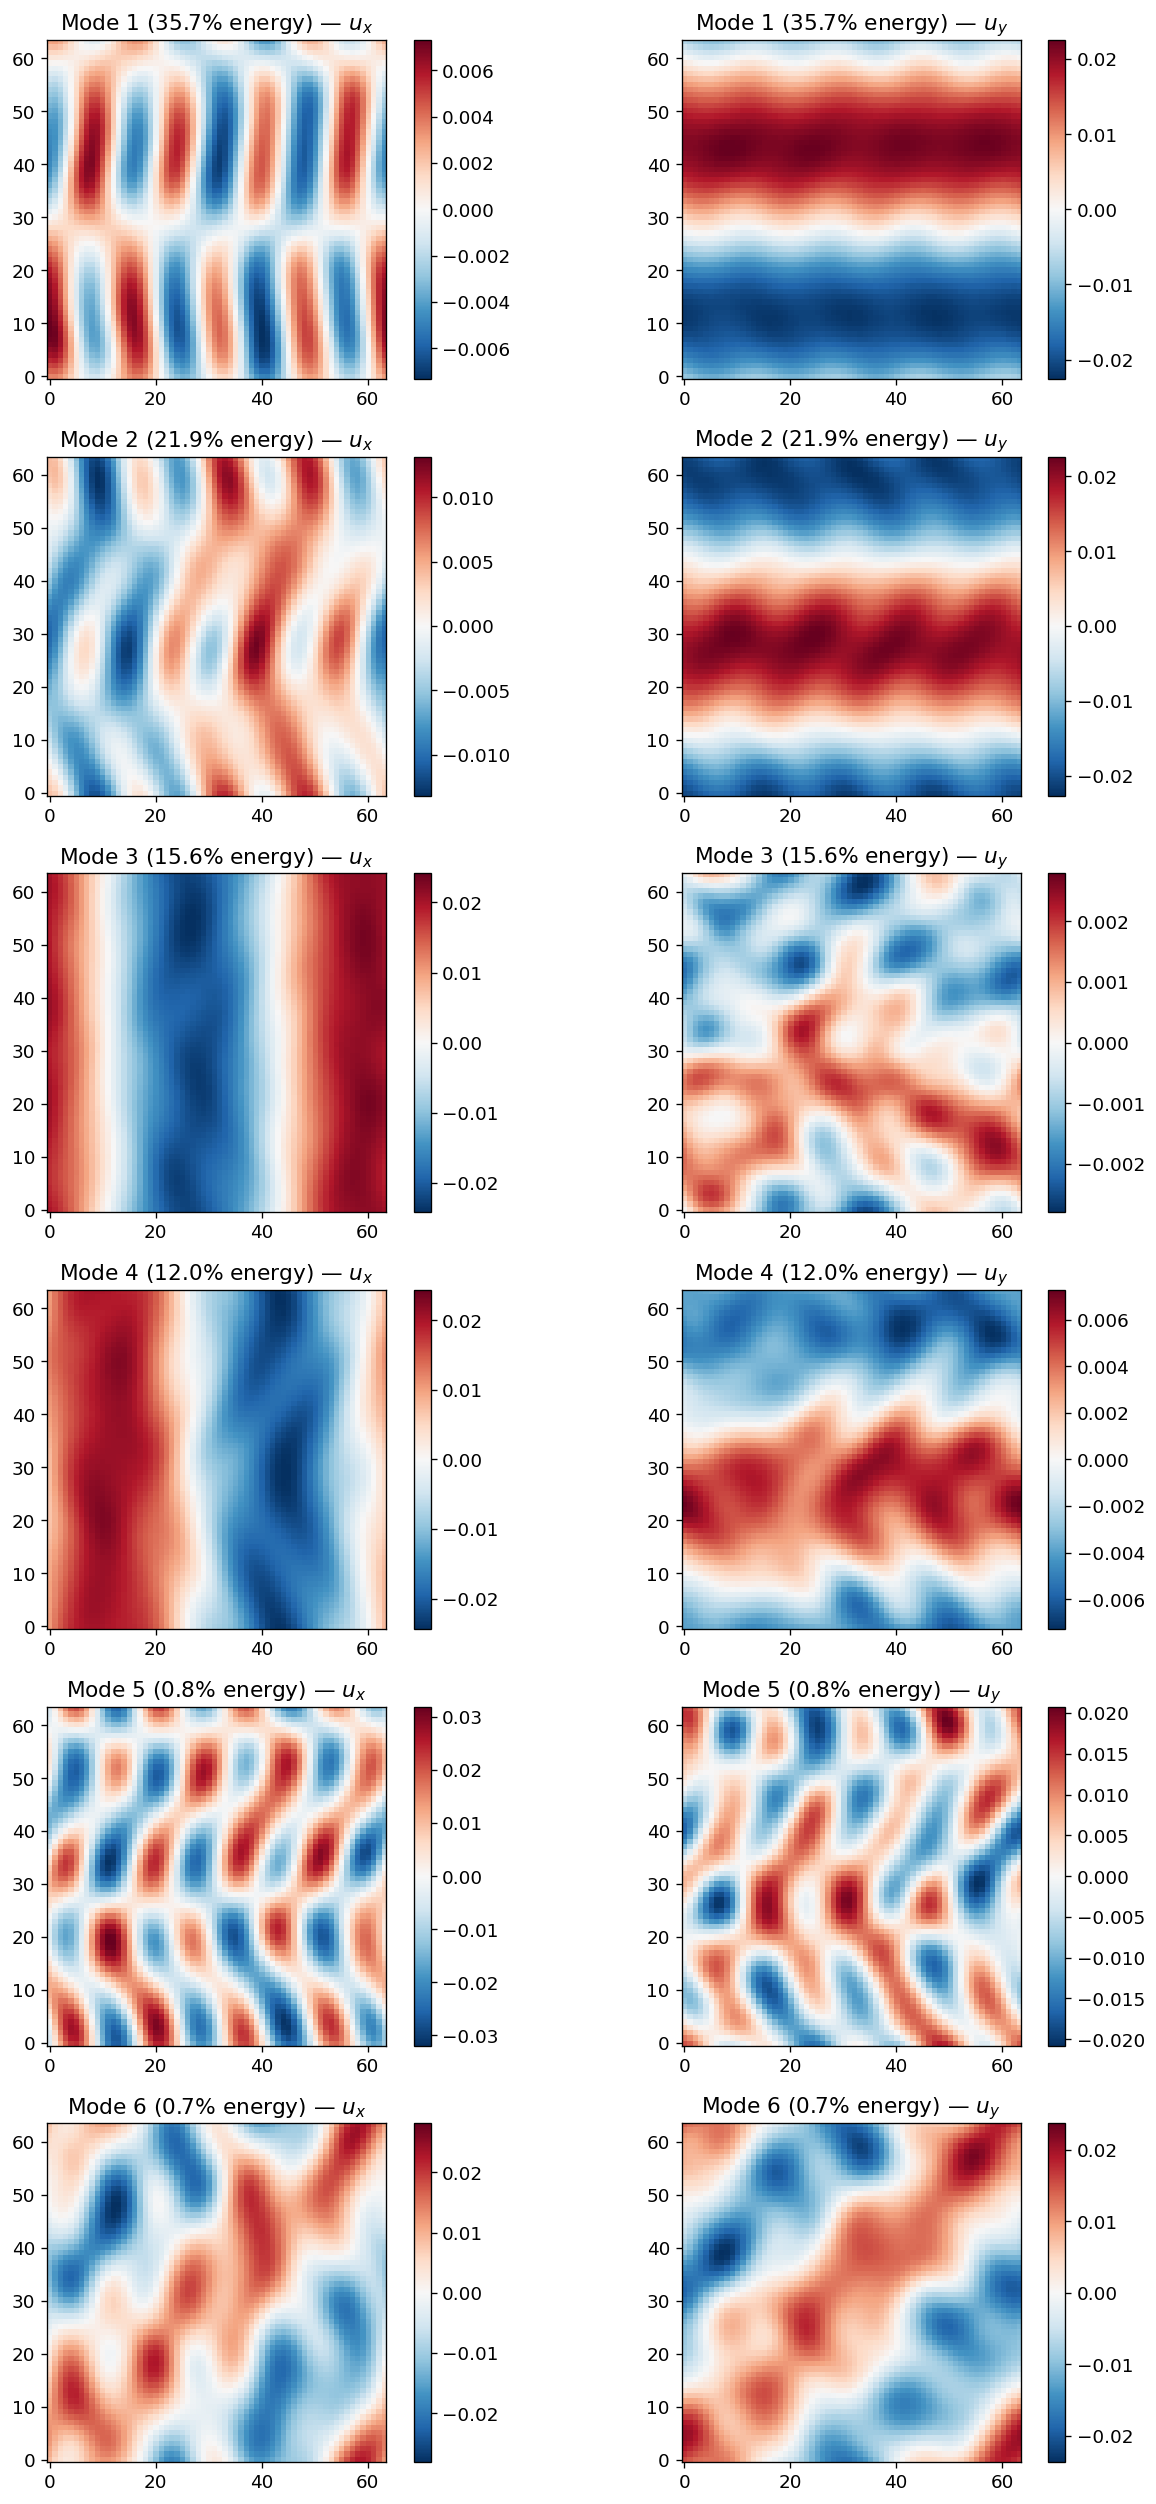

In [9]:
n_modes = 6
half = dl.NY * dl.NX  # 4096

fig, axes = plt.subplots(n_modes, 2, figsize=(12, 3.5*n_modes))
for i in range(n_modes):
    mode_vec = U[:, i]
    ux_mode = mode_vec[:half].reshape(dl.NY, dl.NX)
    uy_mode = mode_vec[half:].reshape(dl.NY, dl.NX)

    for j, (comp, label) in enumerate([(ux_mode, '$u_x$'), (uy_mode, '$u_y$')]):
        ax = axes[i, j]
        vmax = np.abs(comp).max()
        im = ax.imshow(comp, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        pct = energy[i] / energy.sum() * 100
        ax.set_title(f'Mode {i+1} ({pct:.1f}% energy) — {label}')
        ax.set_aspect('equal')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(FIG_DIR / 'step1_spatial_modes.png')
plt.show()

#### 📊 How to Interpret Spatial Modes

| Item | Explanation |
|------|-------------|
| **Figure meaning** | Spatial distribution of first 6 SVD modes; left column: $u_x$ component, right column: $u_y$ component |
| **How to read** | Each mode is a "spatial basis function"; red/blue alternation shows positive/negative regions; earlier modes are more important |
| **Good signal** | Modes exhibit **clear spatial periodicity** (regular stripes/checkerboard/vortex arrays) → system has a characteristic scale |
| **Bad signal** | Modes look like random noise → low energy fraction, not a dominant structure |
| **Key conclusion** | ① Count spatial oscillations (peak-trough alternations) → characteristic wavenumber |  
| | ② Observe if $u_x$ and $u_y$ modes have 90° rotation relationship (rotate symmetry) |
| | ③ Check if modes appear in pairs (e.g., Mode 1&2 similar but phase-shifted) → traveling waves |

### 1.3 Temporal Coefficients

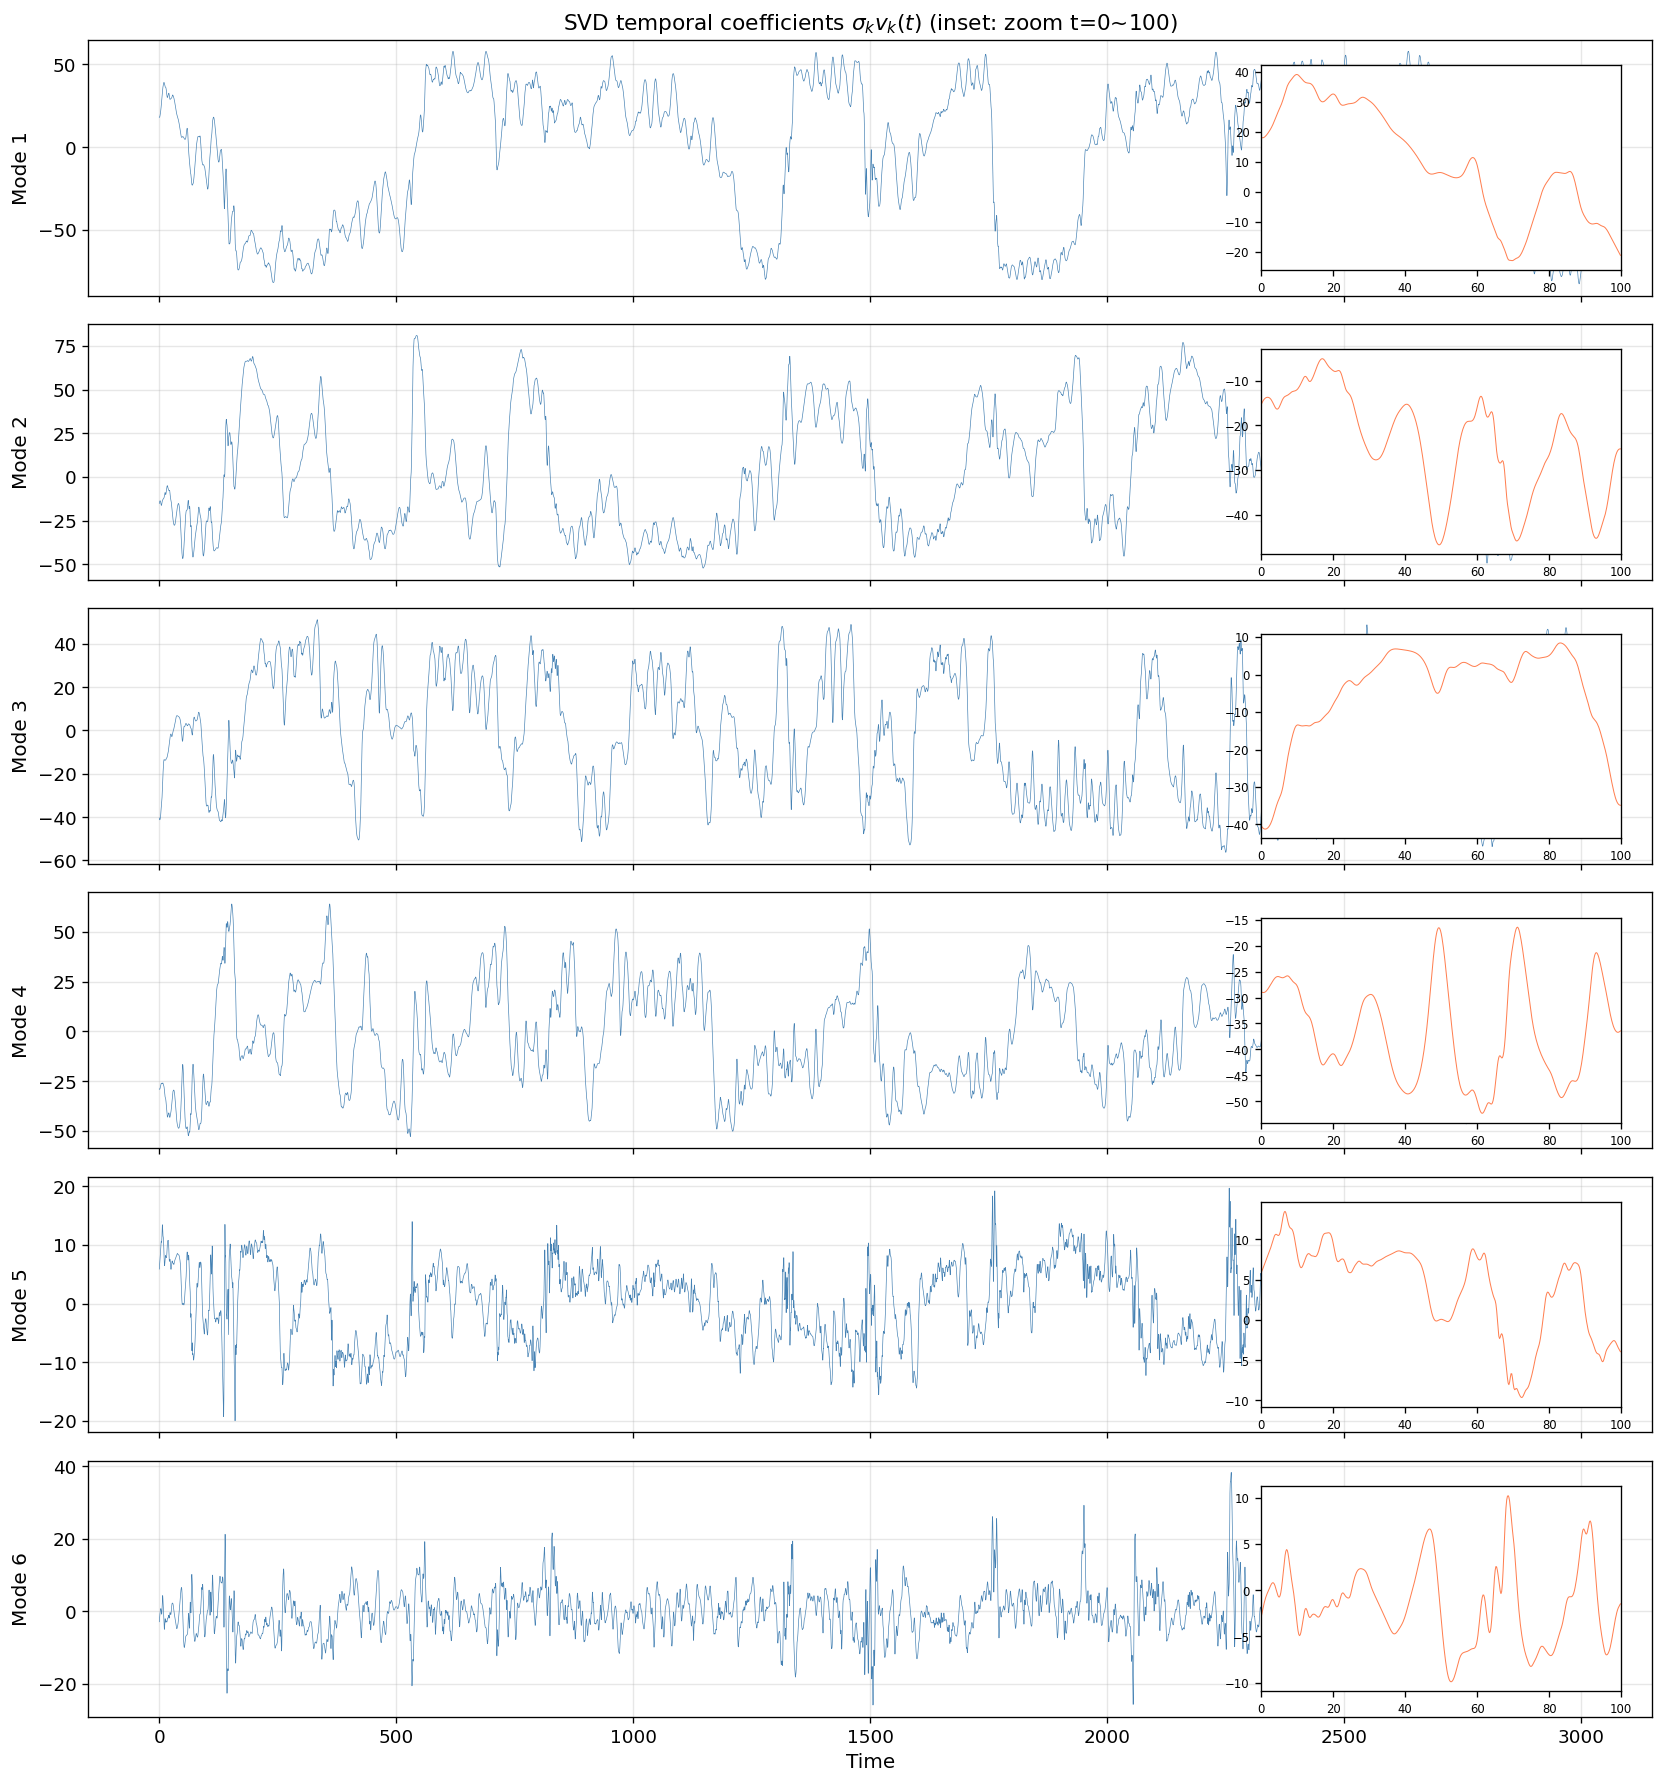

In [10]:
fig, axes = plt.subplots(n_modes, 1, figsize=(14, 2.5*n_modes), sharex=True)
t_arr = np.arange(dl.NT) * dl.DT

for i in range(n_modes):
    coeff = sigma[i] * Vt[i, :]
    ax = axes[i]
    ax.plot(t_arr, coeff, lw=0.4, color='steelblue')
    ax.set_ylabel(f'Mode {i+1}')
    ax.grid(True, alpha=0.3)
    # Show zoomed view
    ax_inset = ax.inset_axes([0.75, 0.1, 0.23, 0.8])
    t_zoom = slice(0, 500)  # First 100 time units
    ax_inset.plot(t_arr[t_zoom], coeff[t_zoom], lw=0.6, color='coral')
    ax_inset.set_xlim(0, 100)
    ax_inset.tick_params(labelsize=7)

axes[-1].set_xlabel('Time')
axes[0].set_title('SVD temporal coefficients $\\sigma_k v_k(t)$ (inset: zoom t=0~100)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'step1_temporal_coeff.png')
plt.show()

#### 📊 How to Interpret Temporal Coefficients

| Item | Explanation |
|------|-------------|
| **Figure meaning** | Temporal evolution of first 6 modes' coefficients $a_k(t) = \sigma_k v_k(t)$; right panel: zoom of first 100 time units |
| **How to read** | Each curve is the time-varying amplitude of that spatial mode; more regular oscillation → clearer temporal frequency |
| **Good signal** | **Regular oscillations** → quasi-periodic motion; **stable amplitude** → statistically steady state |
| **Bad signal** | Amplitude drifts or jumps over time → transient processes or non-stationary behavior |
| **Key conclusion** | ① Do all modes oscillate at same frequency? ② Is there low-frequency modulation? ③ Is system statistically steady? |

### 1.4 Spectral Analysis of Temporal Coefficients

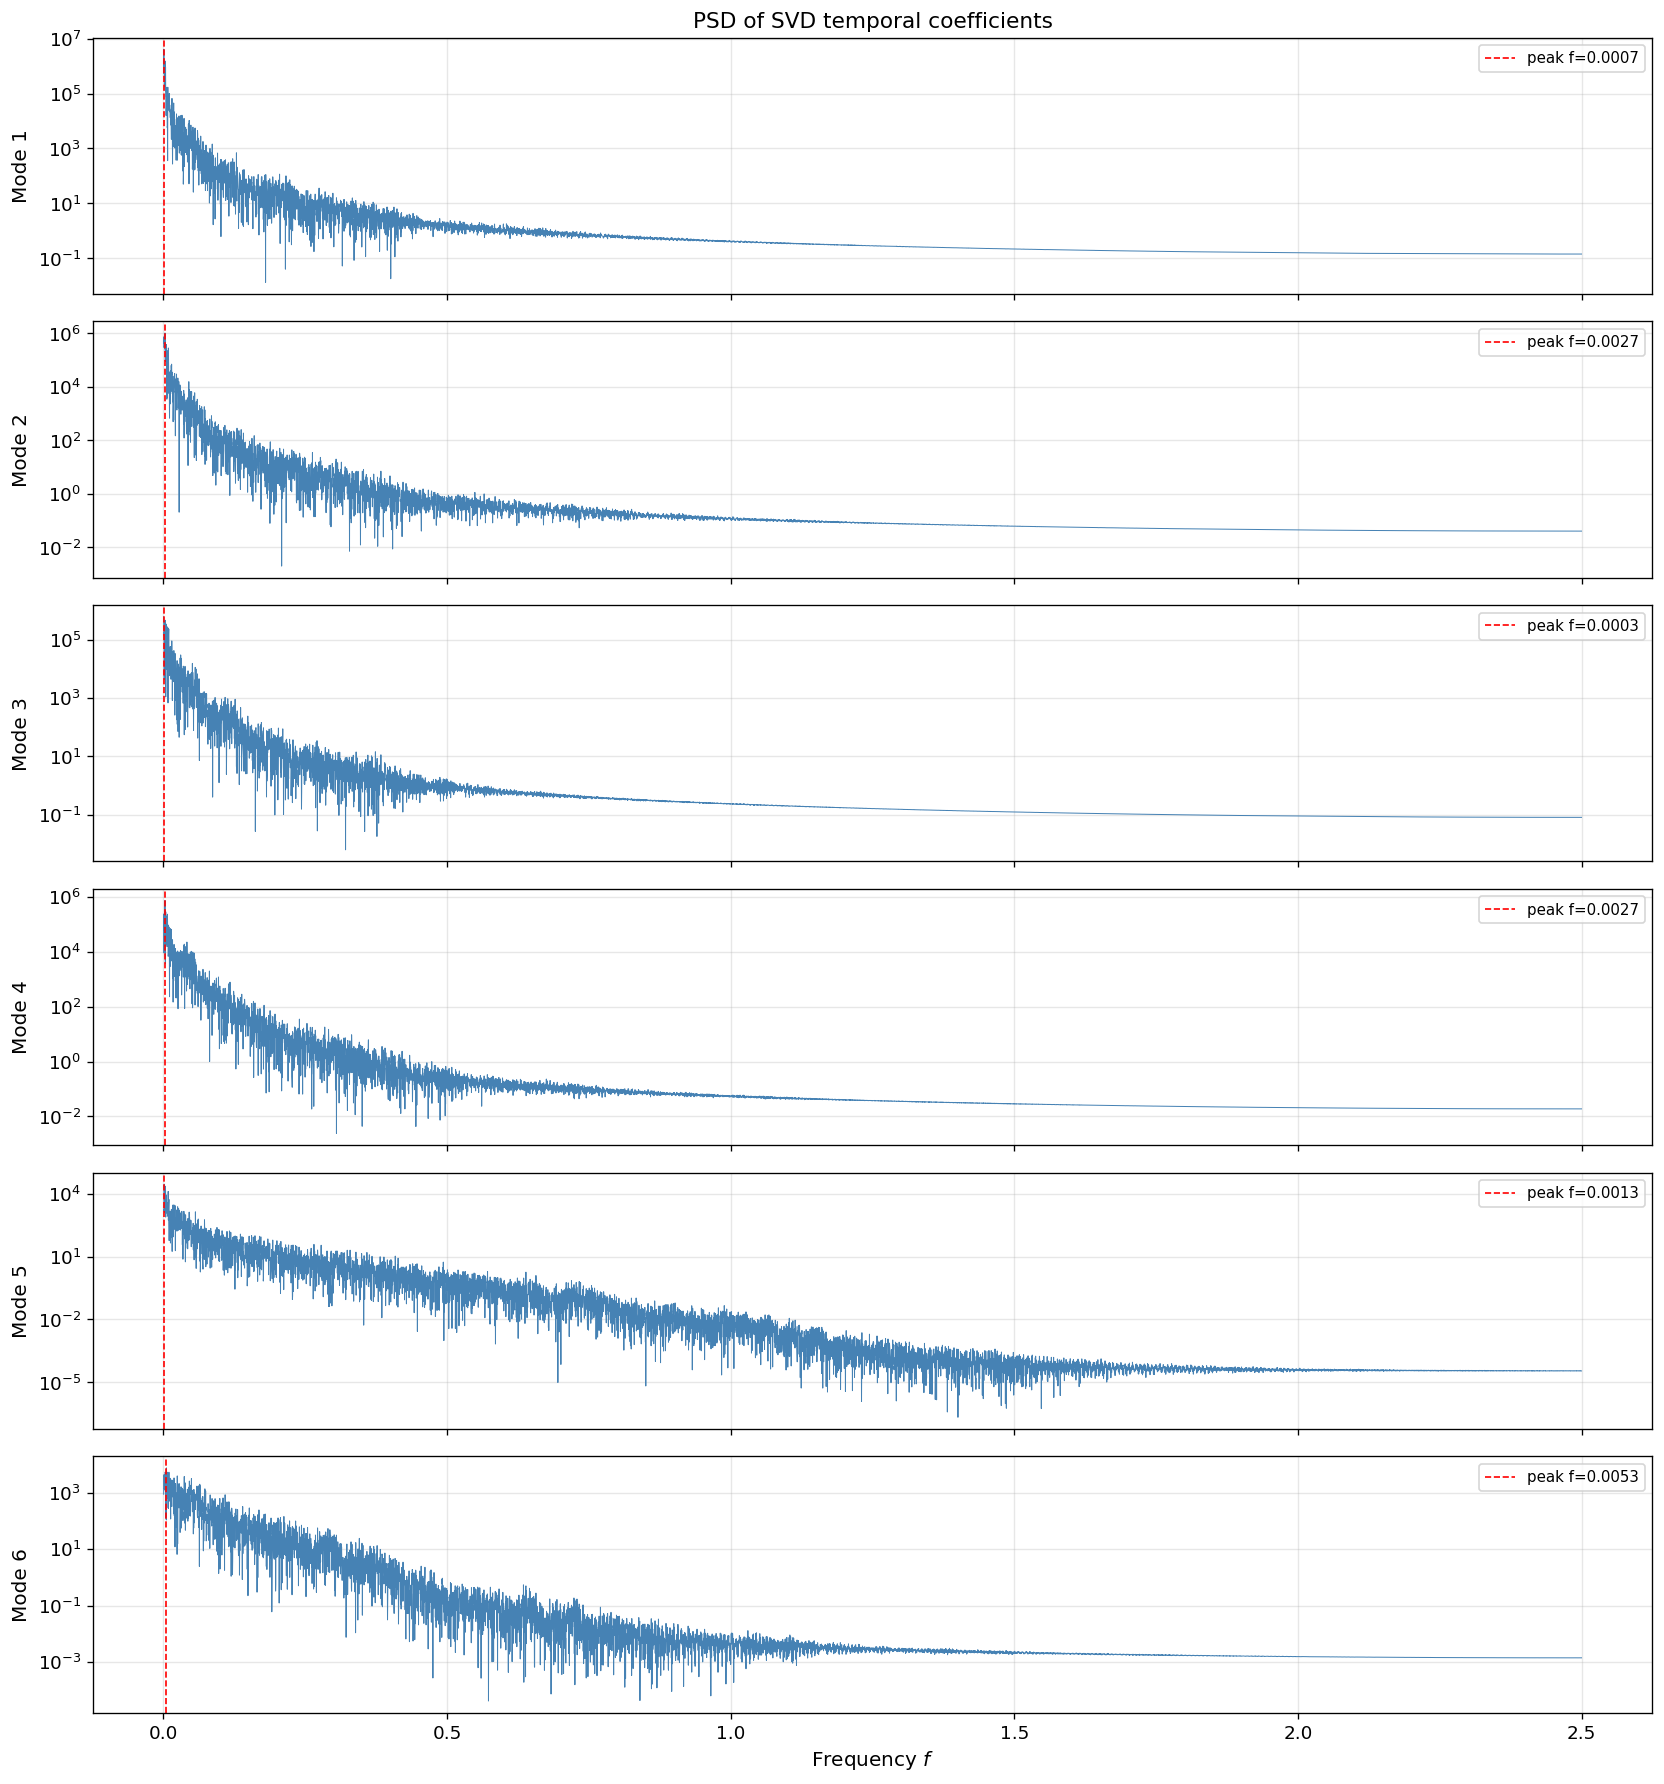

In [11]:
fig, axes = plt.subplots(n_modes, 1, figsize=(14, 2.5*n_modes), sharex=True)
freqs_mode = np.fft.rfftfreq(dl.NT, d=dl.DT)

for i in range(n_modes):
    coeff = sigma[i] * Vt[i, :]
    fhat = np.fft.rfft(coeff)
    psd = np.abs(fhat)**2 / dl.NT
    ax = axes[i]
    ax.semilogy(freqs_mode[1:], psd[1:], lw=0.6, color='steelblue')  # Skip DC
    # Mark peak frequency
    peak_idx = np.argmax(psd[1:]) + 1
    ax.axvline(freqs_mode[peak_idx], color='red', ls='--', lw=1,
               label=f'peak f={freqs_mode[peak_idx]:.4f}')
    ax.set_ylabel(f'Mode {i+1}')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Frequency $f$')
axes[0].set_title('PSD of SVD temporal coefficients')
fig.tight_layout()
fig.savefig(FIG_DIR / 'step1_mode_temporal_psd.png')
plt.show()

#### 📊 How to Interpret Temporal Spectrum of Modes

| Item | Explanation |
|------|-------------|
| **Figure meaning** | Power spectral density of first 6 SVD mode temporal coefficients; x-axis: frequency, y-axis: power (log scale) |
| **How to read** | Sharp peaks (spikes) = mode oscillates **regularly** at that frequency; broadband spectrum = **chaotic/turbulent** |
| **Good signal** | Clear discrete frequency peaks → system has **definite time scales** (corresponding period $T = 1/f$) |
| **Bad signal** | No obvious peaks, power spreads continuously → temporal dynamics more complex/chaotic |
| **Key conclusion** | ① Do all modes have the same dominant frequency? ② If Modes 1&2 share frequency with possible phase difference → traveling waves ③ What time period corresponds to peak frequency? |

---
## Step 2: Fourier Spectral Analysis — Energy Distribution and Periodicity Inference (Project Questions 2 & 3)

Perform Fourier transforms on fluctuation field in **spatial domain** (2D FFT) and **temporal domain** (temporal FFT), analyzing:
- Energy distribution across spatial scales → **Radial power spectrum** $\text{PSD}(k)$
- Presence of external periodic forcing → **Prominent spectral peaks**
- Temporal scale characteristics → **Temporal frequency PSD**

### 2.1 2D Spatial Power Spectrum

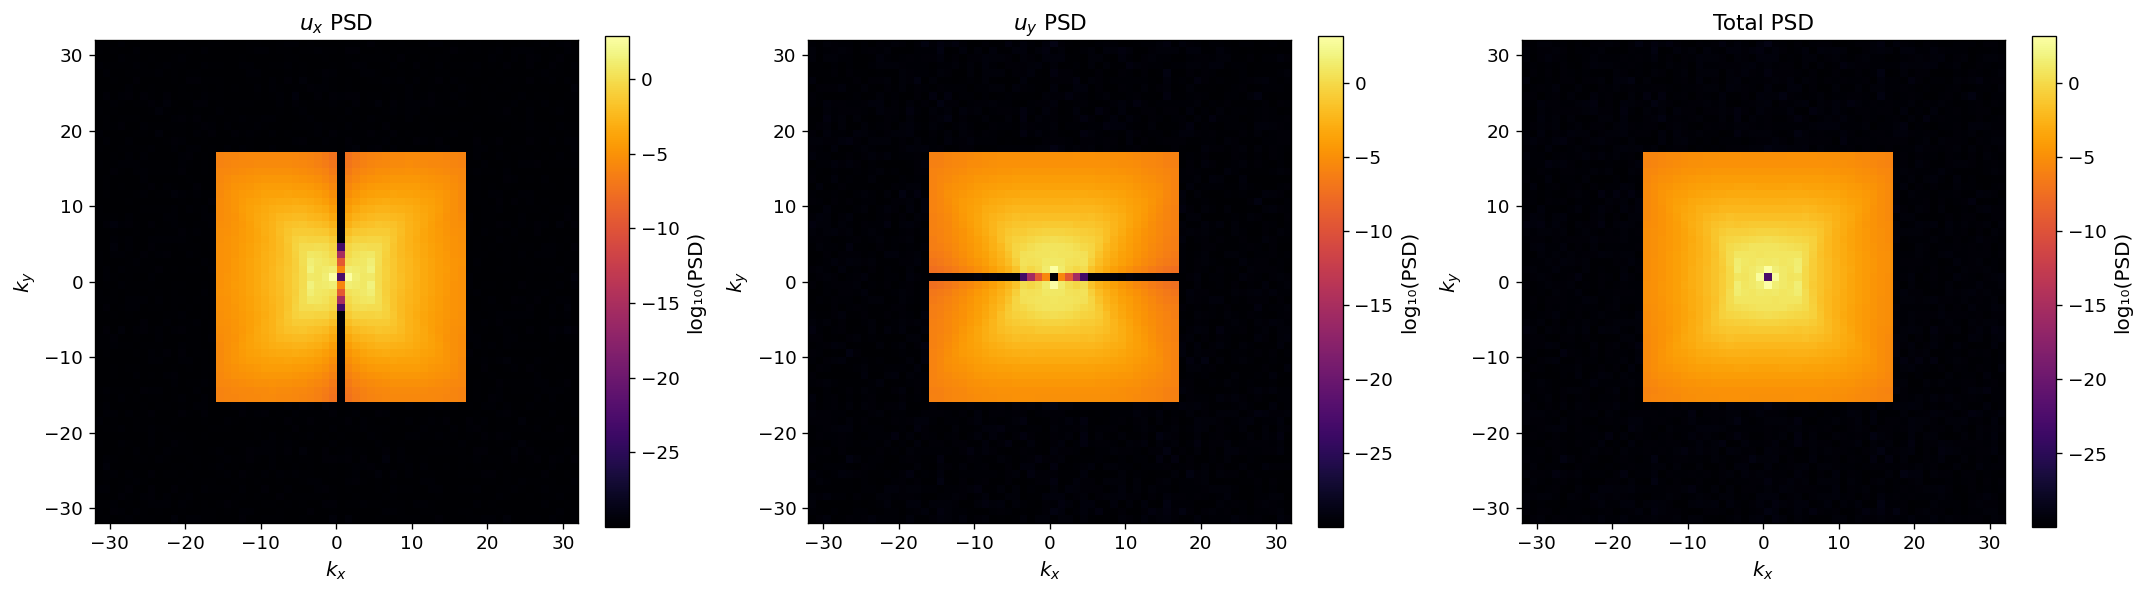

In [12]:
# Compute time-averaged 2D PSD for ux, uy fluctuation fields
def spatial_psd_2d(data_4d, component):
    field = data_4d[..., component]
    fhat = np.fft.fft2(field, axes=(1, 2))
    psd = np.mean(np.abs(fhat)**2, axis=0) / (dl.NX * dl.NY)
    return psd

psd_ux_2d = spatial_psd_2d(fluctuation, 0)
psd_uy_2d = spatial_psd_2d(fluctuation, 1)
psd_total_2d = psd_ux_2d + psd_uy_2d

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, psd, title in zip(axes, [psd_ux_2d, psd_uy_2d, psd_total_2d],
                           ['$u_x$ PSD', '$u_y$ PSD', 'Total PSD']):
    display = np.log10(np.fft.fftshift(psd) + 1e-30)
    n = psd.shape[0]
    extent = [-n//2, n//2, -n//2, n//2]
    im = ax.imshow(display, origin='lower', cmap='inferno', extent=extent)
    ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, label='log₁₀(PSD)')

fig.tight_layout()
fig.savefig(FIG_DIR / 'step2_2d_psd.png')
plt.show()

#### 📊 How to Interpret 2D Power Spectrum

| Item | Explanation |
|------|-------------|
| **Figure meaning** | Power distribution in wavenumber domain $(k_x, k_y)$; center: $k=0$ (large scale), edges: high wavenumbers (small scale) |
| **How to read** | Bright spots/rings = energy concentrated at those wavenumbers; log scale, brighter = higher energy |
| **Good signal** | **Discrete bright spots or rings** → characteristic wavenumber exists, likely from external forcing periodicity |
| **Isotropy check** | Bright areas form **circular rings** → isotropic; distribution differs along $k_x$ or $k_y$ axes → anisotropic |
| **Key conclusion** | ① Find wavenumber $(k_x, k_y)$ with maximum energy concentration, corresponding wavelength $\lambda = L/k$ ② If obvious **isolated bright spots** (not diffuse) → likely external periodic forcing exists |

### 2.2 Radial Power Spectrum & Peak Wavenumber Detection

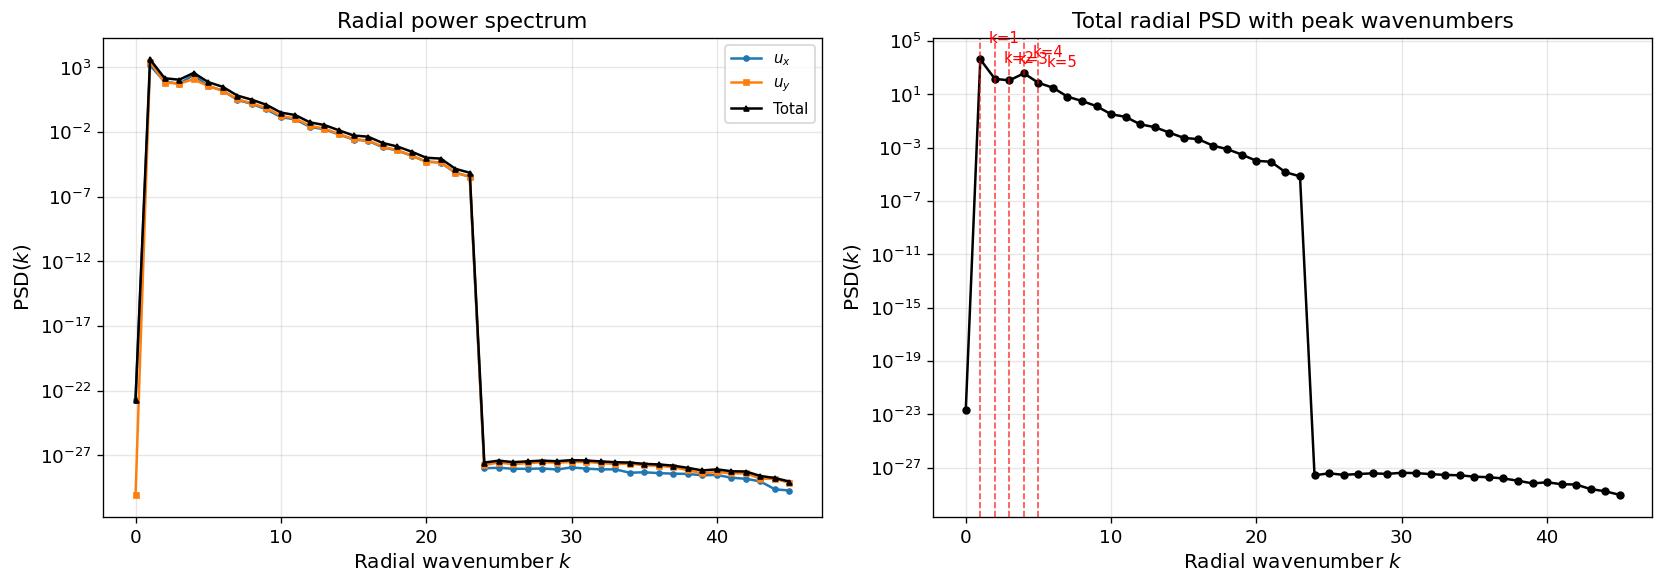


🔍 Top 5 peak wavenumbers (excluding DC):
  k = 1,  PSD = 4.1676e+03,  energy fraction = 84.80%
  k = 4,  PSD = 3.7524e+02,  energy fraction = 7.64%
  k = 2,  PSD = 1.4534e+02,  energy fraction = 2.96%
  k = 3,  PSD = 1.1060e+02,  energy fraction = 2.25%
  k = 5,  PSD = 7.2597e+01,  energy fraction = 1.48%


In [13]:
def radial_spectrum(psd_2d):
    ny, nx = psd_2d.shape
    kx = np.fft.fftfreq(nx) * nx
    ky = np.fft.fftfreq(ny) * ny
    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)
    k_max = int(np.floor(K.max()))
    k_bins = np.arange(0, k_max + 1)
    psd_rad = np.zeros(len(k_bins))
    for i, k in enumerate(k_bins):
        mask = (K >= k - 0.5) & (K < k + 0.5)
        if mask.any():
            psd_rad[i] = psd_2d[mask].sum()
    return k_bins, psd_rad

k_bins, rad_ux = radial_spectrum(psd_ux_2d)
_, rad_uy = radial_spectrum(psd_uy_2d)
_, rad_total = radial_spectrum(psd_total_2d)

# Peak detection
rad_total_nodc = rad_total.copy()
rad_total_nodc[0] = 0
top5_idx = np.argsort(rad_total_nodc)[::-1][:5]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: three radial spectra
axes[0].semilogy(k_bins, rad_ux, 'o-', ms=3, label='$u_x$')
axes[0].semilogy(k_bins, rad_uy, 's-', ms=3, label='$u_y$')
axes[0].semilogy(k_bins, rad_total, '^-', ms=3, label='Total', color='k')
axes[0].set_xlabel('Radial wavenumber $k$')
axes[0].set_ylabel('PSD($k$)')
axes[0].set_title('Radial power spectrum')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: expanded + annotated peaks
axes[1].semilogy(k_bins, rad_total, 'o-', ms=4, color='k')
for idx in top5_idx:
    axes[1].axvline(k_bins[idx], color='red', ls='--', lw=1, alpha=0.7)
    axes[1].annotate(f'k={k_bins[idx]:.0f}', (k_bins[idx], rad_total[idx]),
                     textcoords='offset points', xytext=(5, 10),
                     fontsize=9, color='red')
axes[1].set_xlabel('Radial wavenumber $k$')
axes[1].set_ylabel('PSD($k$)')
axes[1].set_title('Total radial PSD with peak wavenumbers')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / 'step2_radial_spectrum.png')
plt.show()

print("\n🔍 Top 5 peak wavenumbers (excluding DC):")
for idx in top5_idx:
    print(f"  k = {k_bins[idx]:.0f},  PSD = {rad_total[idx]:.4e},  "
          f"energy fraction = {rad_total[idx]/rad_total.sum()*100:.2f}%")

#### 📊 How to Interpret Radial Power Spectrum

| Item | Explanation |
|------|-------------|
| **Figure meaning** | 2D PSD integrated over radial wavenumber $k=\sqrt{k_x^2+k_y^2}$ to get 1D energy distribution |
| **How to read** | X-axis: radial wavenumber (larger = smaller spatial scales), y-axis: total energy at that scale |
| **Good signal** | **Sharp prominent peak** at some wavenumber $k_0$, far above surroundings → that scale dominates, likely from external forcing |
| **Bad signal** | Flat spectrum without obvious peaks → energy distributed uniformly across all scales |
| **Key conclusion** | ① Peak wavenumber $k_{\text{peak}}$ corresponds to characteristic wavelength $\lambda = L/k_{\text{peak}}$, where $L$ is domain size ② If peak very prominent (>20% energy), can strongly infer **external forcing injected that scale** ③ Compare $u_x$ vs $u_y$ peak positions to judge if both components dominated by same scale |

### 2.3 Temporal Frequency Power Spectrum

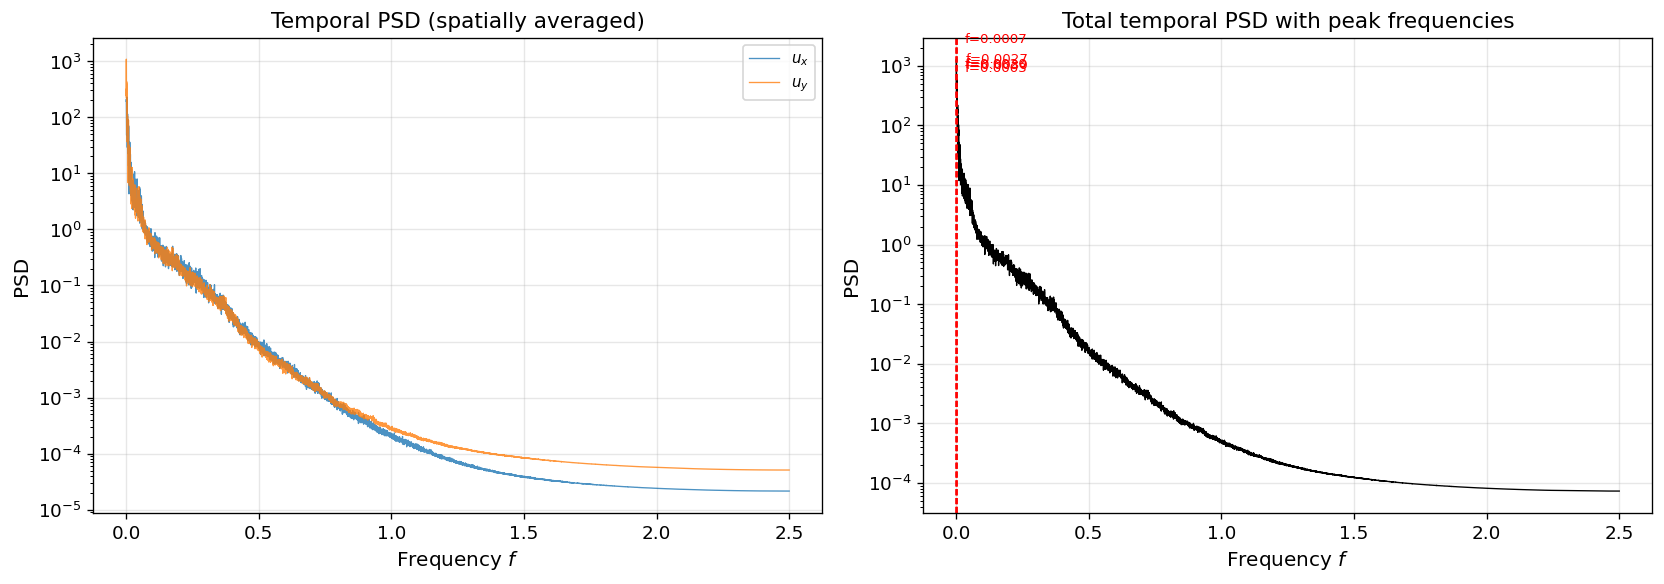


🔍 Top 5 peak frequencies:
  f = 0.000667,  T = 1500.00,  PSD = 1.2911e+03
  f = 0.002667,  T = 375.00,  PSD = 5.9214e+02
  f = 0.002000,  T = 500.00,  PSD = 4.9749e+02
  f = 0.003000,  T = 333.33,  PSD = 4.7763e+02
  f = 0.000333,  T = 3000.00,  PSD = 4.1572e+02


In [14]:
def temporal_psd_avg(data_4d, component, dt):
    field = data_4d[..., component]
    nt = field.shape[0]
    fhat = np.fft.rfft(field, axis=0)
    psd = np.mean(np.abs(fhat)**2, axis=(1, 2)) / nt
    freqs = np.fft.rfftfreq(nt, d=dt)
    return freqs, psd

freqs_t, tpsd_ux = temporal_psd_avg(fluctuation, 0, dl.DT)
_, tpsd_uy = temporal_psd_avg(fluctuation, 1, dl.DT)
tpsd_total = tpsd_ux + tpsd_uy

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: ux vs uy
axes[0].semilogy(freqs_t[1:], tpsd_ux[1:], lw=0.8, label='$u_x$', alpha=0.8)
axes[0].semilogy(freqs_t[1:], tpsd_uy[1:], lw=0.8, label='$u_y$', alpha=0.8)
axes[0].set_xlabel('Frequency $f$')
axes[0].set_ylabel('PSD')
axes[0].set_title('Temporal PSD (spatially averaged)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: total PSD + peak annotation
tpsd_total_nodc = tpsd_total.copy()
tpsd_total_nodc[0] = 0
top5_freq_idx = np.argsort(tpsd_total_nodc)[::-1][:5]

axes[1].semilogy(freqs_t[1:], tpsd_total[1:], lw=0.8, color='k')
for idx in top5_freq_idx:
    if freqs_t[idx] > 0:
        axes[1].axvline(freqs_t[idx], color='red', ls='--', lw=1, alpha=0.7)
        axes[1].annotate(f'f={freqs_t[idx]:.4f}', (freqs_t[idx], tpsd_total[idx]),
                         textcoords='offset points', xytext=(5, 10), fontsize=8, color='red')
axes[1].set_xlabel('Frequency $f$')
axes[1].set_ylabel('PSD')
axes[1].set_title('Total temporal PSD with peak frequencies')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / 'step2_temporal_psd.png')
plt.show()

print("\n🔍 Top 5 peak frequencies:")
for idx in top5_freq_idx:
    if freqs_t[idx] > 0:
        print(f"  f = {freqs_t[idx]:.6f},  T = {1/freqs_t[idx]:.2f},  PSD = {tpsd_total[idx]:.4e}")

#### 📊 How to Interpret Temporal Power Spectrum

| Item | Explanation |
|------|-------------|
| **Figure meaning** | Time FFT at each grid point then spatially averaged, showing energy distribution across temporal scales |
| **How to read** | X-axis: temporal frequency $f$ (Nyquist = $1/(2\Delta t) = 2.5$), y-axis: power |
| **Good signal** | Discrete frequency peaks → system has **definite time periods**; peaks consistent with SVD mode frequencies → structural consistency |
| **Bad signal** | Broadband flat spectrum → temporal dynamics more chaotic, no characteristic time scale |
| **Key conclusion** | ① Peak frequency corresponds to period $T=1/f$, the system's characteristic time scale ② Compare $u_x$ vs $u_y$ temporal spectra: similar shape → isotropic; different → anisotropic |

---
## Step 3: Symmetry and Anisotropy Diagnosis (Project Question 4)

Diagnose system symmetry and anisotropy through:
1. **Mirror/rotation symmetry tests** of Fourier spectrum
2. **Comparison of $k_x$ vs $k_y$ axis slices**
3. **Difference in radial spectra** between $u_x$ and $u_y$ components
4. **Component energy ratio** $E_{u_x} / E_{u_y}$

### 3.1 Quantitative Symmetry Tests of Spectrum

In [15]:
# Mirror symmetry: PSD(kx, ky) vs PSD(-kx, ky) and PSD(kx, -ky)
flip_x = np.flip(psd_total_2d, axis=1)
flip_y = np.flip(psd_total_2d, axis=0)
rotated_90 = psd_total_2d.T

norm = np.sum(psd_total_2d**2)
err_mirror_x = np.sum((psd_total_2d - flip_x)**2) / norm
err_mirror_y = np.sum((psd_total_2d - flip_y)**2) / norm
err_rot90 = np.sum((psd_total_2d - rotated_90)**2) / norm

print("=== 2D PSD Symmetry Tests ===")
print(f"x-mirror symmetry error:  {err_mirror_x:.6e}  {'✅ Symmetric' if err_mirror_x < 1e-6 else '⚠️ Asymmetric'}")
print(f"y-mirror symmetry error:  {err_mirror_y:.6e}  {'✅ Symmetric' if err_mirror_y < 1e-6 else '⚠️ Asymmetric'}")
print(f"90° rotation symmetry error: {err_rot90:.6e}  {'✅ Isotropic' if err_rot90 < 1e-6 else '⚠️ Anisotropic'}")

# Component energy ratio
E_ux = np.mean(fluctuation[..., 0]**2)
E_uy = np.mean(fluctuation[..., 1]**2)
ratio = E_ux / E_uy
print(f"\n=== Component Energy ===")
print(f"E(ux) = {E_ux:.6e}")
print(f"E(uy) = {E_uy:.6e}")
print(f"E(ux)/E(uy) = {ratio:.4f}  {'✅ Isotropic' if abs(ratio-1) < 0.05 else '⚠️ Anisotropic'}")

=== 2D PSD Symmetry Tests ===
x-mirror symmetry error:  1.915311e+00  ⚠️ Asymmetric
y-mirror symmetry error:  1.947085e+00  ⚠️ Asymmetric
90° rotation symmetry error: 3.637610e-01  ⚠️ Anisotropic

=== Component Energy ===
E(ux) = 4.617944e-01
E(uy) = 7.380001e-01
E(ux)/E(uy) = 0.6257  ⚠️ Anisotropic


### 3.2 Comparison of $k_x$ vs $k_y$ Axis Slices

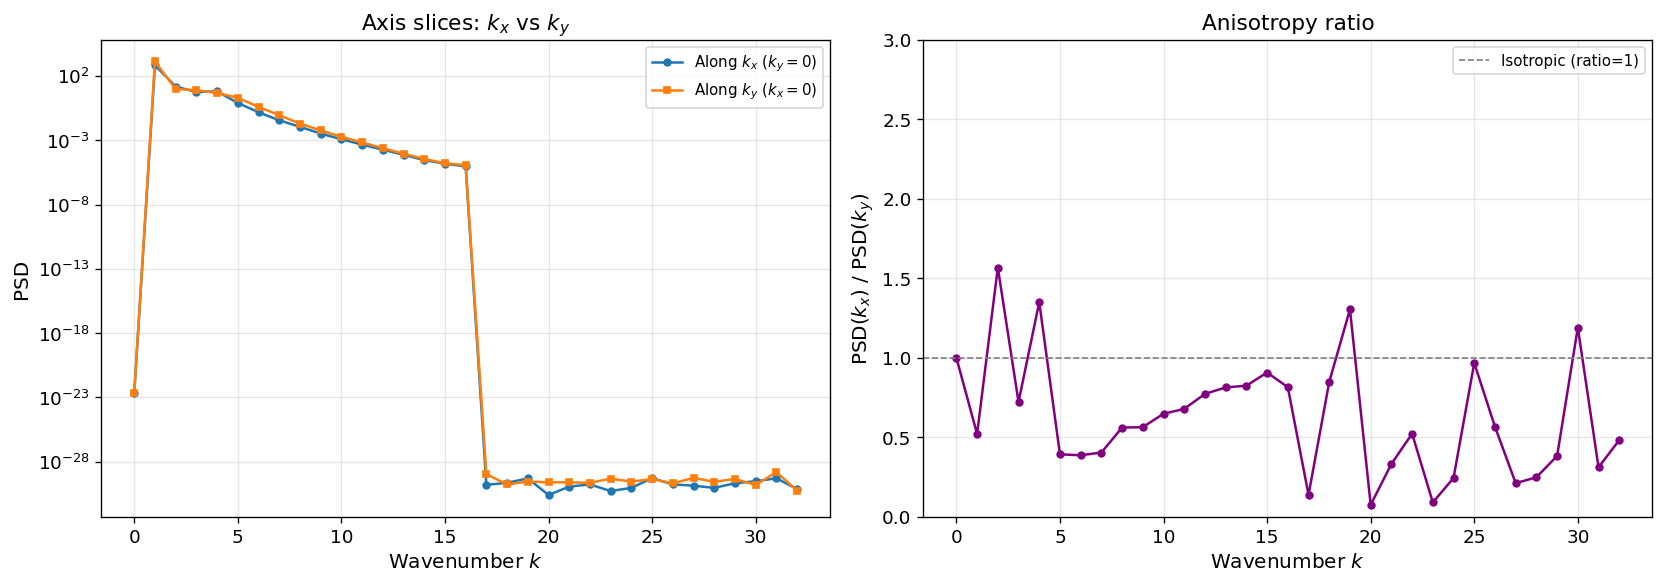

In [16]:
# Take slices along kx axis (ky=0) and ky axis (kx=0)
psd_kx_slice = psd_total_2d[0, :dl.NX//2+1]   # ky=0, kx=0..32
psd_ky_slice = psd_total_2d[:dl.NY//2+1, 0]    # kx=0, ky=0..32
k_1d = np.arange(dl.NX // 2 + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: direct comparison
axes[0].semilogy(k_1d, psd_kx_slice, 'o-', ms=4, label='Along $k_x$ ($k_y=0$)')
axes[0].semilogy(k_1d, psd_ky_slice, 's-', ms=4, label='Along $k_y$ ($k_x=0$)')
axes[0].set_xlabel('Wavenumber $k$')
axes[0].set_ylabel('PSD')
axes[0].set_title('Axis slices: $k_x$ vs $k_y$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: anisotropy ratio
aniso_ratio = psd_kx_slice / (psd_ky_slice + 1e-30)
axes[1].plot(k_1d, aniso_ratio, 'o-', ms=4, color='purple')
axes[1].axhline(1.0, color='gray', ls='--', lw=1, label='Isotropic (ratio=1)')
axes[1].set_xlabel('Wavenumber $k$')
axes[1].set_ylabel('PSD($k_x$) / PSD($k_y$)')
axes[1].set_title('Anisotropy ratio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, max(3, aniso_ratio[1:].max() * 1.2))

fig.tight_layout()
fig.savefig(FIG_DIR / 'step3_anisotropy_kx_ky.png')
plt.show()

### 3.3 Comparison of $u_x$ vs $u_y$ Component Radial Spectra

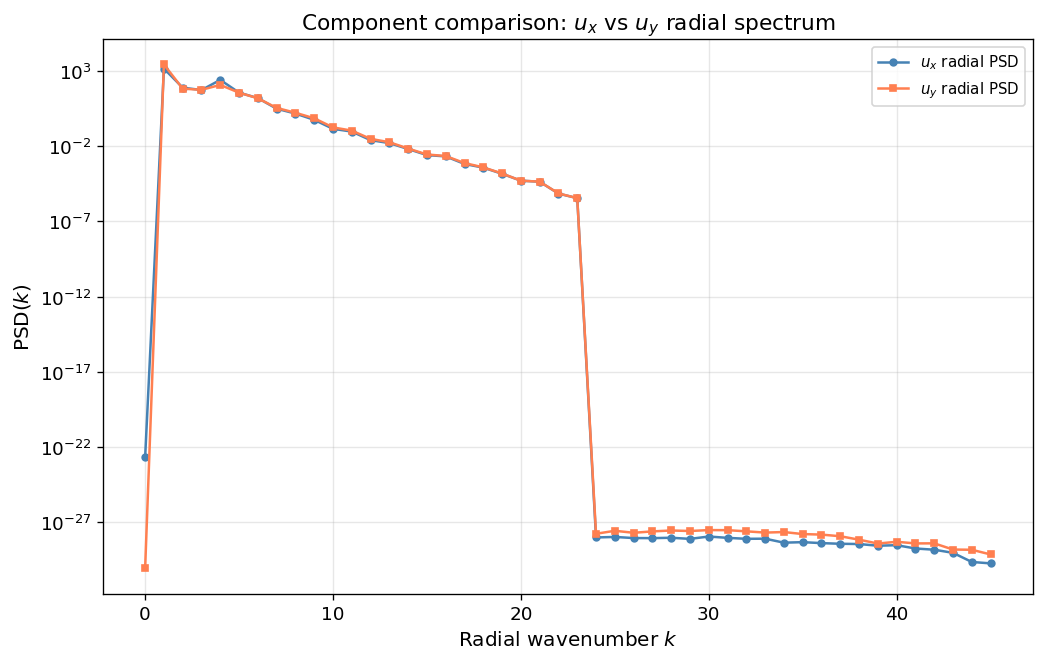

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(k_bins, rad_ux, 'o-', ms=4, label='$u_x$ radial PSD', color='steelblue')
ax.semilogy(k_bins, rad_uy, 's-', ms=4, label='$u_y$ radial PSD', color='coral')
ax.set_xlabel('Radial wavenumber $k$')
ax.set_ylabel('PSD($k$)')
ax.set_title('Component comparison: $u_x$ vs $u_y$ radial spectrum')
ax.legend()
ax.grid(True, alpha=0.3)
fig.savefig(FIG_DIR / 'step3_component_comparison.png')
plt.show()

#### 📊 How to Interpret Symmetry & Anisotropy Results

| Item | Explanation |
|------|-------------|
| **Mirror symmetry error** | Error $< 10^{-6}$ → spectrum highly symmetric in that direction; $> 10^{-2}$ → obvious asymmetry |
| **90° rotation symmetry** | Very small error → system **isotropic** ($k_x$, $k_y$ directions equivalent); large error → **anisotropic** |
| **Anisotropy ratio (ratio)** | Ratio ≈ 1 at all $k$ → isotropic; deviation from 1 at some $k$ → directional preference at that scale |
| **Component energy ratio** | $E(u_x)/E(u_y) \approx 1$ → components statistically equivalent; deviation → system has directional preference |
| **$u_x$ vs $u_y$ radial spectra** | Curves overlap → isotropic; peak positions differ → components dominated by different scales |
| **Key conclusion** | Combine above indicators to determine symmetry type: isotropic/mirror-symmetric only/fully anisotropic |

### 3.4 SVD Spatial Mode Symmetry Check

In [18]:
half = dl.NY * dl.NX
print("=== First 6 SVD Modes Spatial Symmetry (Correlation Coefficients) ===")
print(f"{'Mode':>5} {'ux mirror-x':>12} {'ux mirror-y':>12} {'uy mirror-x':>12} {'uy mirror-y':>12}")
print("-" * 58)

for i in range(6):
    ux_m = U[:half, i].reshape(dl.NY, dl.NX)
    uy_m = U[half:, i].reshape(dl.NY, dl.NX)

    def corr(a, b):
        return np.corrcoef(a.flatten(), b.flatten())[0, 1]

    cx_ux = corr(ux_m, np.flip(ux_m, axis=1))
    cy_ux = corr(ux_m, np.flip(ux_m, axis=0))
    cx_uy = corr(uy_m, np.flip(uy_m, axis=1))
    cy_uy = corr(uy_m, np.flip(uy_m, axis=0))

    print(f"{i+1:>5} {cx_ux:>+12.3f} {cy_ux:>+12.3f} {cx_uy:>+12.3f} {cy_uy:>+12.3f}")

print()
print("Interpretation: +1 = fully symmetric, -1 = fully antisymmetric, 0 = uncorrelated")

=== First 6 SVD Modes Spatial Symmetry (Correlation Coefficients) ===
 Mode  ux mirror-x  ux mirror-y  uy mirror-x  uy mirror-y
----------------------------------------------------------
    1       +0.802       -0.504       +0.995       -0.715
    2       -0.010       +0.697       +0.993       +0.737
    3       +0.642       +0.996       +0.662       -0.172
    4       -0.660       +0.991       +0.942       +0.335
    5       -0.631       +0.093       +0.416       +0.021
    6       -0.181       +0.008       +0.160       +0.115

Interpretation: +1 = fully symmetric, -1 = fully antisymmetric, 0 = uncorrelated


#### 📊 How to Interpret Mode Symmetry

| Correlation Value | Meaning |
|-------------------|----------|
| ≈ **+1** | Mode **mirror-symmetric** about that axis (even symmetry) |
| ≈ **−1** | Mode **antisymmetric** about that axis (odd symmetry) |
| ≈ **0** | Mode uncorrelated with its mirror, **no symmetry** in that direction |

If multiple dominant modes exhibit consistent symmetry (e.g., all symmetric about x-axis), the **system itself possesses that directional symmetry**.

---
## 📋 Analysis Summary

### Q1: Leading Spatial Structure (SVD Analysis)
- Reaching 95% energy requires **32 modes**, 99% requires **72 modes**
- **First 4 modes dominate**: Mode 1 (35.72%) + Mode 2 (21.94%) + Mode 3 (15.65%) + Mode 4 (12.03%) = **85.34%**
- **Significant energy gap** between Mode 4→5 (12.03% drops to 0.83%), indicating first 4 modes capture core spatial structure
- Leading modes show **large-scale organized stripe patterns**, consistent with dominant wavenumber $k=1$

### Q2: Spatial Scale Distribution of Energy
- Peak wavenumber $k_{\text{peak}} = 1$ contains **84.80%** of energy, representing **domain-scale structures** (one wavelength spans full domain $L$)
- Secondary peak at $k = 4$ contains **7.64%**, a significant secondary scale
- Energy decays stepwise for $k \leq 20$, drops to noise level (~$10^{-27}$) for $k > 22$, indicating sufficient spatial resolution with minimal small-scale energy

### Q3: Inference of External Periodic Forcing
- **Presence of prominent spectral peaks**: ✅ Yes, extremely prominent
- $k = 1$ dominance at 84.80%; secondary peak at $k = 4$ (7.64%) clearly above background decay trend
- **Inferred forcing wavenumber**: $k = 4$ most likely corresponds to "prescribed spatially periodic external forcing" in project description, as it's the most prominent discrete peak above background; $k = 1$ dominance may reflect system's natural large-scale response
- **Evidence strength**: Strong — sharp concentrated peaks, highly non-uniform energy distribution

### Q4: Symmetry and Anisotropy
- **Mirror symmetry**: ❌ — x/y mirror errors of 1.92/1.95 show spectrum lacks simple mirror symmetry
- **Isotropy**: ❌ — 90° rotation error = 0.36; $E(u_x)/E(u_y) = 0.6257$ ($u_y$ ~60% higher than $u_x$), system is **clearly anisotropic**
- **SVD Mode Symmetry Features**:
  - Modes 1&2 $u_y$ components show strong x-direction mirror symmetry (correlation ≈ +0.99)
  - Modes 3&4 $u_x$ components show strong y-direction mirror symmetry (correlation ≈ +0.99)
  - System overall anisotropic, but **dominant modes have structured symmetries** (different modes symmetric in different directions)
- **Temporal Characteristics**: Temporal PSD shows broadband decay without sharp discrete peaks; energy concentrated at very low frequencies ($f \approx 0.0007 \sim 0.003$, periods $T \approx 333 \sim 1500$ time units), indicating **complex multi-scale temporal dynamics**, not simple periodic oscillation

### Additional Findings
- **Divergence**: Global divergence/velocity ratio = 0.199, system is **not strictly incompressible**, divergence contributes significantly (RMS ≈ 0.16), must be considered in physical interpretation
- **Data Statistics**: $u_x$ std = 0.707, $u_y$ std = 0.931, confirming $u_y$ component is statistically more active

> **📁 All figures saved to `figures/` directory, ready for Overleaf report inclusion.**

---
## 📊 Composite Figure for Report (Single 2×2 Figure Covering Q1–Q4)

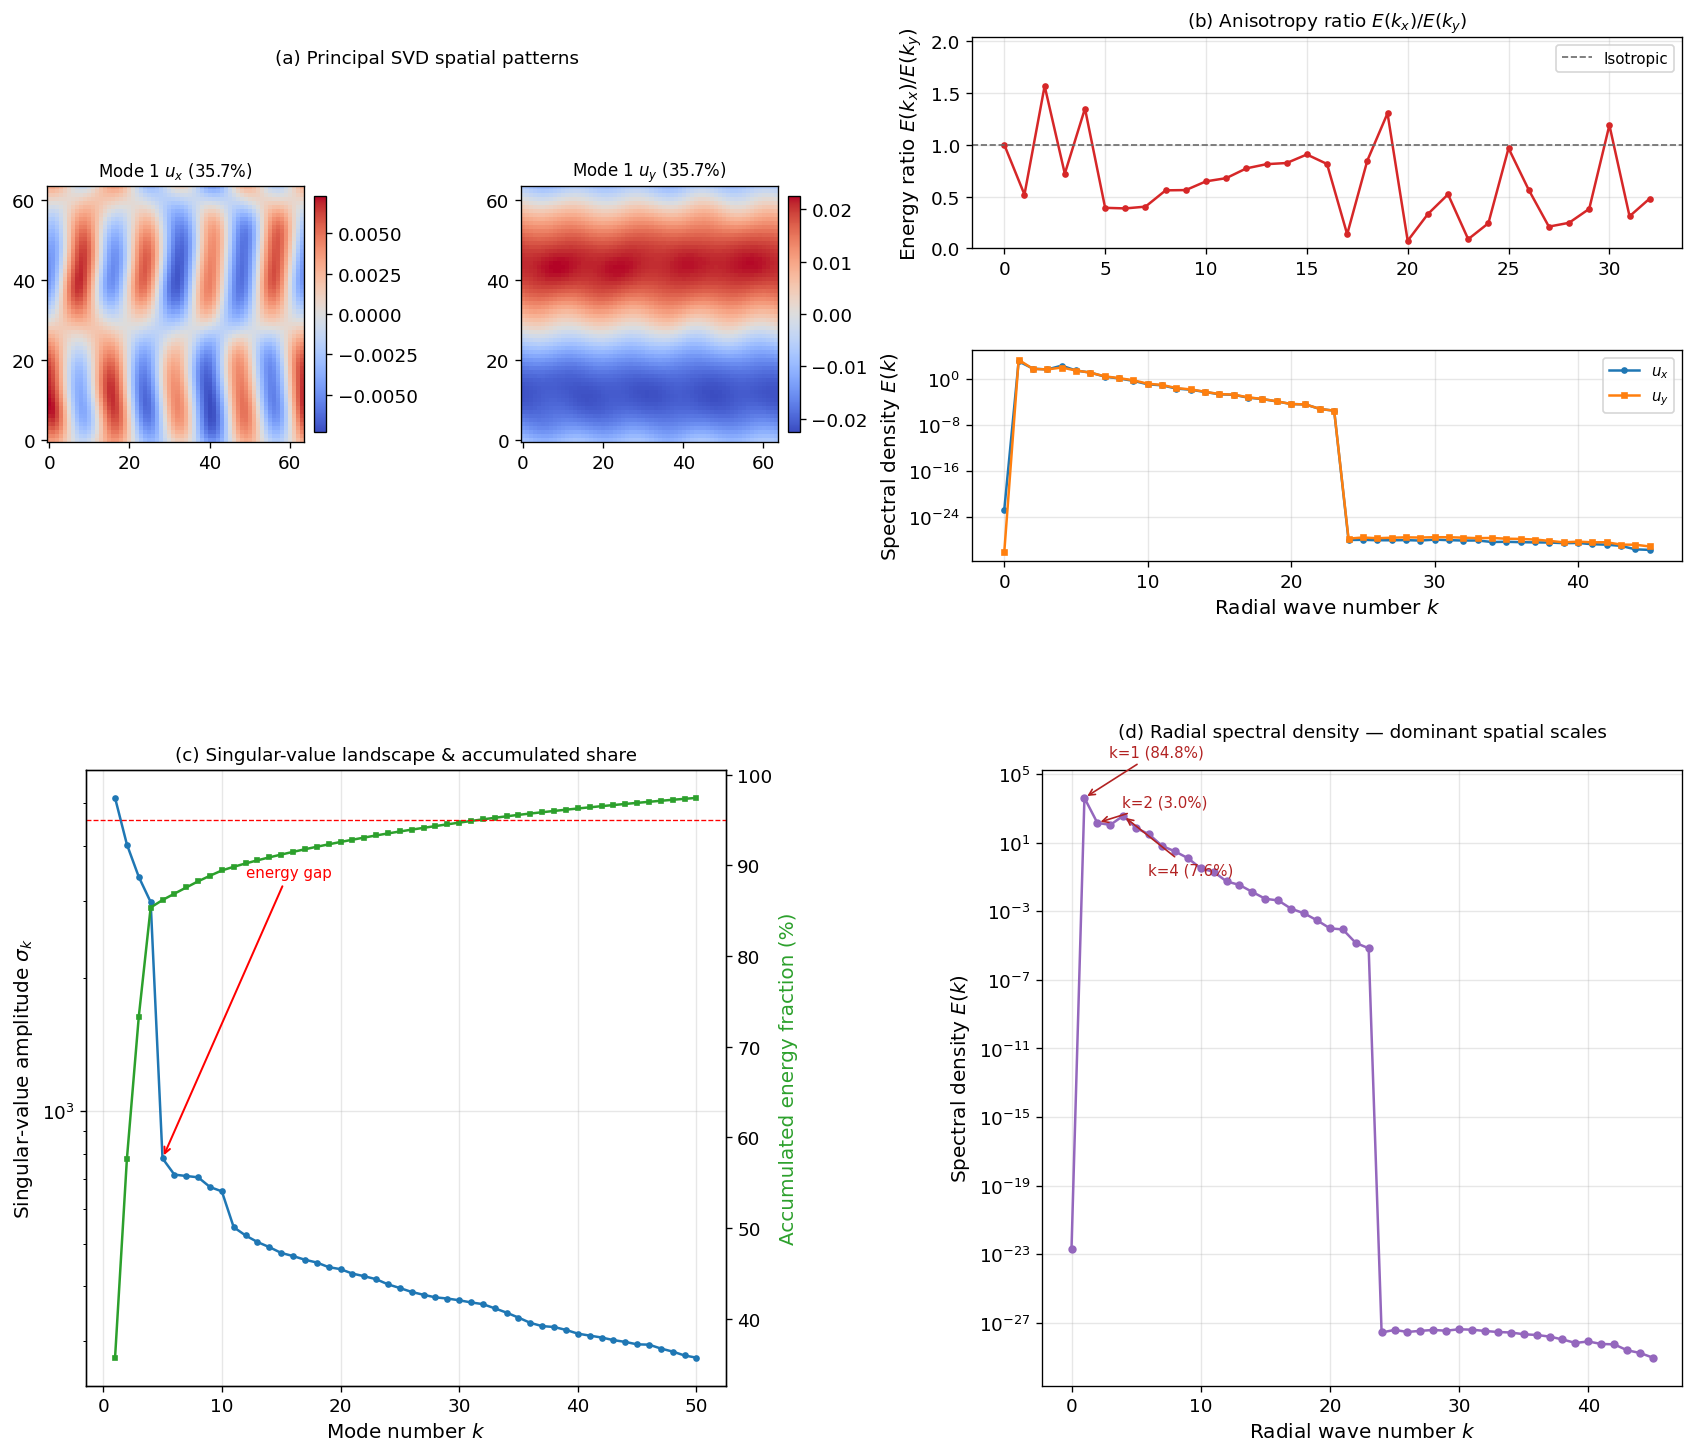

✅ Saved: figures/report_composite_figure.png & .pdf


In [19]:
fig = plt.figure(figsize=(14, 12), constrained_layout=True)
gs = fig.add_gridspec(2, 2, hspace=0.28, wspace=0.18)

# ── (a) Mode 1 spatial patterns ux & uy ── Q1 visual evidence（移动到左上）
half = dl.NY * dl.NX
mode1_ux = U[:half, 0].reshape(dl.NY, dl.NX)
mode1_uy = U[half:, 0].reshape(dl.NY, dl.NX)

gs_a = gs[0, 0].subgridspec(1, 2, wspace=0.08)
ax_a1 = fig.add_subplot(gs_a[0])
ax_a2 = fig.add_subplot(gs_a[1])

vmax_ux = np.abs(mode1_ux).max()
vmax_uy = np.abs(mode1_uy).max()
im_a1 = ax_a1.imshow(mode1_ux, origin='lower', cmap='coolwarm',
                     vmin=-vmax_ux, vmax=vmax_ux)
ax_a1.set_title(f'Mode 1 $u_x$ ({energy[0]/energy.sum()*100:.1f}%)', fontsize=10)
ax_a1.set_aspect('equal')
fig.colorbar(im_a1, ax=ax_a1, fraction=0.046, pad=0.04)

im_a2 = ax_a2.imshow(mode1_uy, origin='lower', cmap='coolwarm',
                     vmin=-vmax_uy, vmax=vmax_uy)
ax_a2.set_title(f'Mode 1 $u_y$ ({energy[0]/energy.sum()*100:.1f}%)', fontsize=10)
ax_a2.set_aspect('equal')
fig.colorbar(im_a2, ax=ax_a2, fraction=0.046, pad=0.04)

fig.text(0.25, 0.97, '(a) Principal SVD spatial patterns', fontsize=11,
         ha='center', va='top')

# ── (b) ux vs uy radial spectra + anisotropy ratio ── Q4（移动到右上）
gs_b = gs[0, 1].subgridspec(2, 1, hspace=0.10)
ax_b1 = fig.add_subplot(gs_b[0])
ax_b2 = fig.add_subplot(gs_b[1])

# Top: anisotropy ratio E(k_x)/E(k_y)
psd_kx_sl = psd_total_2d[0, :dl.NX//2+1]
psd_ky_sl = psd_total_2d[:dl.NY//2+1, 0]
k_1d_loc = np.arange(dl.NX // 2 + 1)
ratio_line = psd_kx_sl / (psd_ky_sl + 1e-30)
ax_b1.plot(k_1d_loc, ratio_line, 'o-', ms=3, color='tab:red')
ax_b1.axhline(1.0, color='dimgray', ls='--', lw=1, label='Isotropic')
ax_b1.set_ylabel('Energy ratio $E(k_x)/E(k_y)$')
ax_b1.set_title('(b) Anisotropy ratio $E(k_x)/E(k_y)$', fontsize=11)
ax_b1.legend(fontsize=9)
ax_b1.grid(True, alpha=0.3)
ax_b1.set_ylim(0, min(5, ratio_line[1:].max() * 1.3))

# Bottom: ux / uy radial spectra
ax_b2.semilogy(k_bins, rad_ux, 'o-', ms=3, label='$u_x$', color='tab:blue')
ax_b2.semilogy(k_bins, rad_uy, 's-', ms=3, label='$u_y$', color='tab:orange')
ax_b2.set_xlabel('Radial wave number $k$')
ax_b2.set_ylabel('Spectral density $E(k)$')
ax_b2.legend(fontsize=9)
ax_b2.grid(True, alpha=0.3)

# ── (c) Singular spectrum + accumulated energy share ── Q1（移动到左下）
ax_c = fig.add_subplot(gs[1, 0])
n_show = 50
ax_c.semilogy(np.arange(1, n_show+1), sigma[:n_show], 'o-', ms=3,
              color='tab:blue', label='$\sigma_k$')
ax_c.set_xlabel('Mode number $k$')
ax_c.set_ylabel('Singular-value amplitude $\sigma_k$')
ax_c.grid(True, alpha=0.3)

ax_c2 = ax_c.twinx()
ax_c2.plot(np.arange(1, n_show+1), cum_energy[:n_show]*100, 's-', ms=2.5,
           color='tab:green', label='Accumulated fraction')
ax_c2.axhline(95, color='r', ls='--', lw=0.8)
ax_c2.set_ylabel('Accumulated energy fraction (%)', color='tab:green')

ax_c.annotate('energy gap',
              xy=(5, sigma[4]), xytext=(12, sigma[2]),
              arrowprops=dict(arrowstyle='->', color='red', lw=1.2),
              fontsize=9, color='red')
ax_c.set_title('(c) Singular-value landscape & accumulated share', fontsize=11)

# ── (d) Radial spectral density + dominant scales ── Q2 & Q3（移动到右下）
ax_d = fig.add_subplot(gs[1, 1])
ax_d.semilogy(k_bins, rad_total, 'o-', ms=4, color='tab:purple', label='Total PSD')

rad_nodc = rad_total.copy(); rad_nodc[0] = 0
top3 = np.argsort(rad_nodc)[::-1][:3]
offsets = [(15, 25), (15, -35), (15, 10)]
for i, idx in enumerate(top3):
    frac = rad_total[idx] / rad_total.sum() * 100
    ax_d.annotate(f'k={k_bins[idx]:.0f} ({frac:.1f}%)',
                  xy=(k_bins[idx], rad_total[idx]),
                  xytext=offsets[i], textcoords='offset points',
                  arrowprops=dict(arrowstyle='->', color='firebrick', lw=1),
                  fontsize=9, color='firebrick', ha='left')
ax_d.set_xlabel('Radial wave number $k$')
ax_d.set_ylabel('Spectral density $E(k)$')
ax_d.set_title('(d) Radial spectral density — dominant spatial scales', fontsize=11, pad=20)
ax_d.grid(True, alpha=0.3)

fig.savefig(FIG_DIR / 'report_composite_figure.png', dpi=300)
fig.savefig(FIG_DIR / 'report_composite_figure.pdf')   # PDF vector format better for LaTeX
plt.show()
print("✅ Saved: figures/report_composite_figure.png & .pdf")

---
## Composite figure used in the report

The following cell regenerates the **final 2×2 composite figure** used in the report, summarising dominant spatial structures (Q1), spectral scales and forcing signatures (Q2–Q3), and anisotropy diagnostics (Q4).

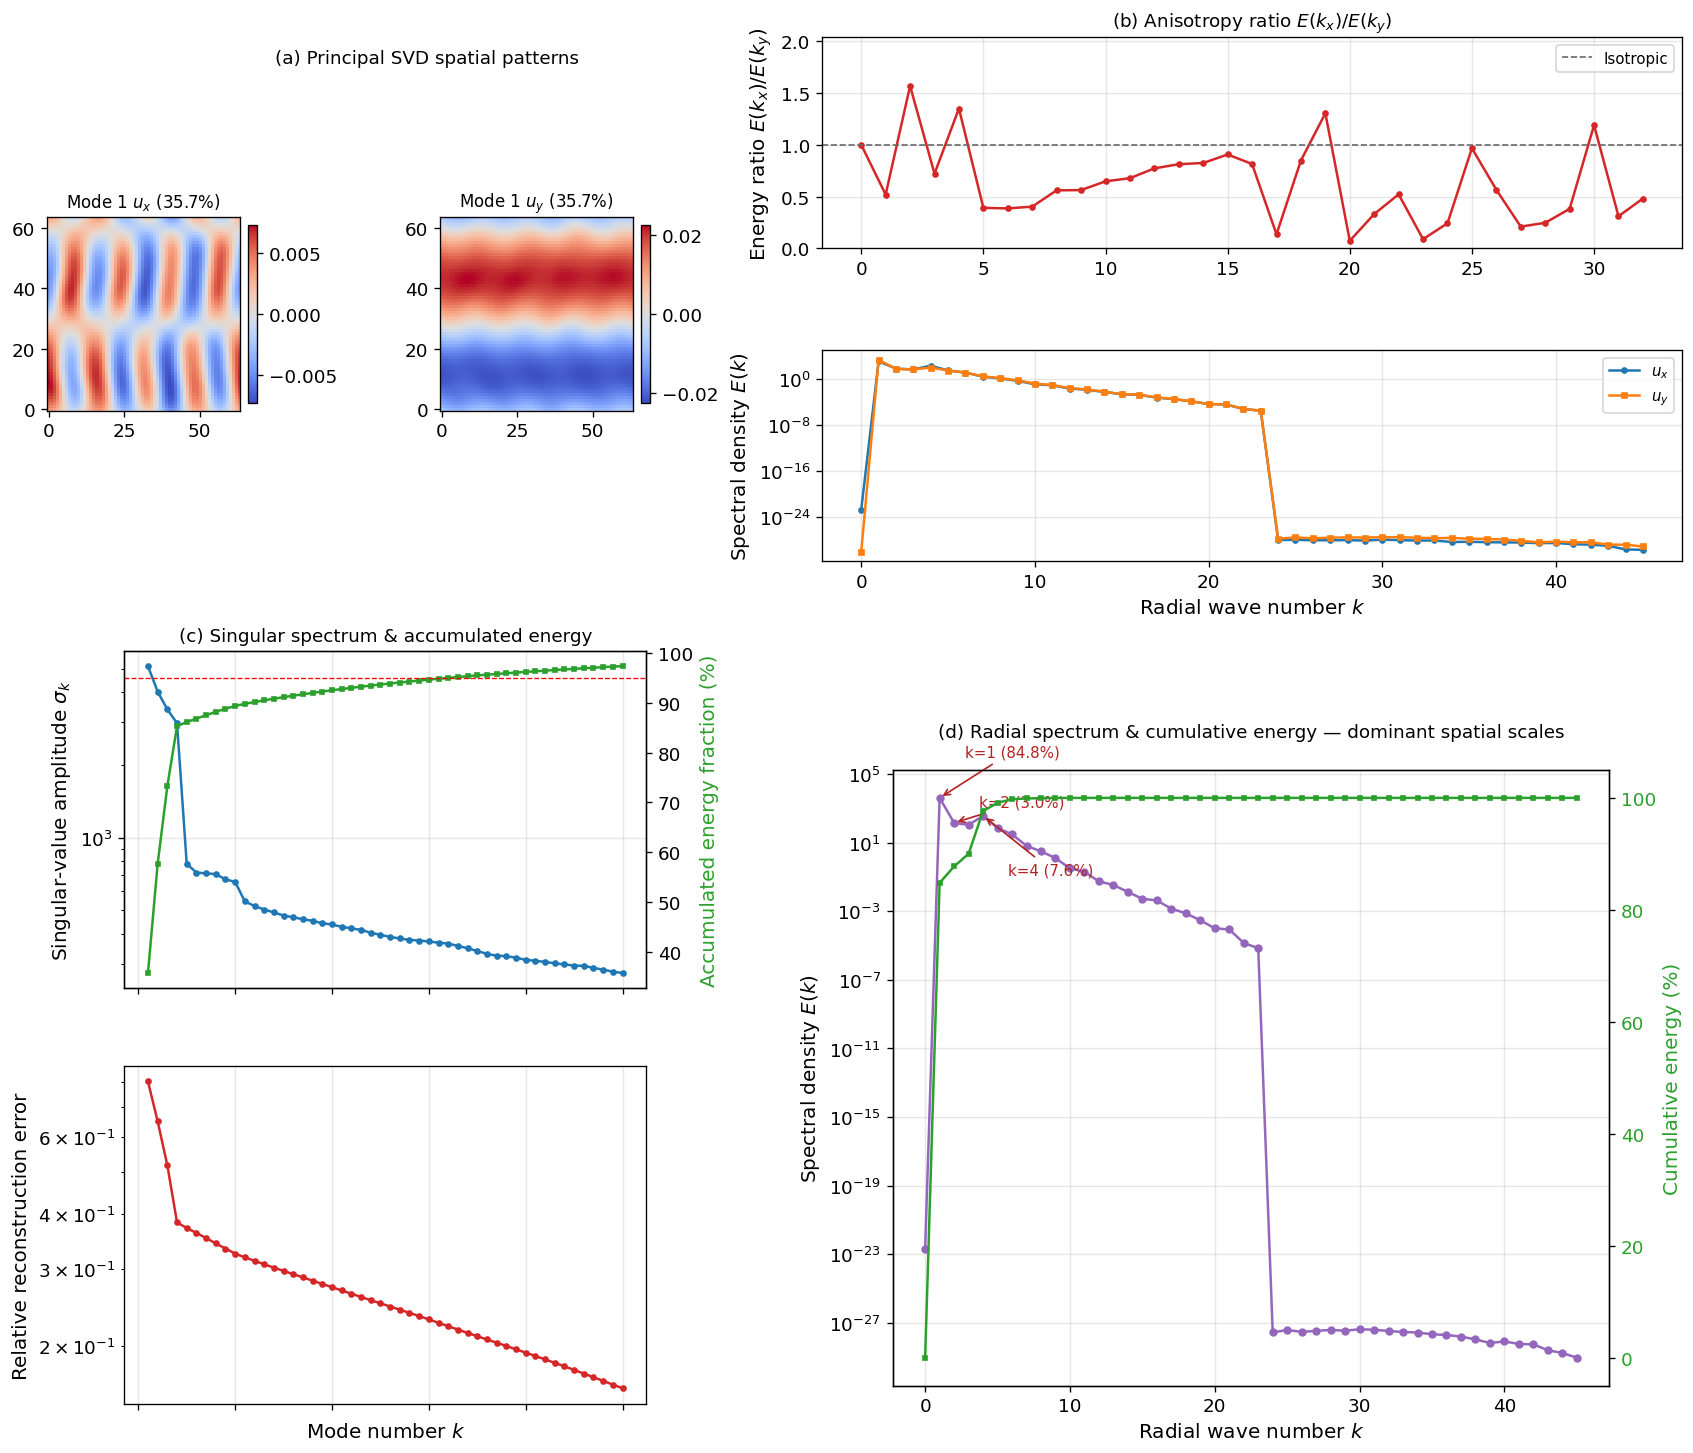

✅ Saved UPDATED composite figure: figures/report_composite_figure.png & .pdf


In [20]:
# Updated composite figure for the report
# This overwrites figures/report_composite_figure.[png,pdf]
# using both the original panels and a few extended diagnostics.

fig = plt.figure(figsize=(14, 12), constrained_layout=True)
gs = fig.add_gridspec(2, 2, hspace=0.28, wspace=0.18)

# ── (a) Mode 1 spatial patterns ux & uy ── Q1
half = dl.NY * dl.NX
mode1_ux = U[:half, 0].reshape(dl.NY, dl.NX)
mode1_uy = U[half:, 0].reshape(dl.NY, dl.NX)

gs_a = gs[0, 0].subgridspec(1, 2, wspace=0.08)
ax_a1 = fig.add_subplot(gs_a[0])
ax_a2 = fig.add_subplot(gs_a[1])

vmax_ux = np.abs(mode1_ux).max()
vmax_uy = np.abs(mode1_uy).max()
im_a1 = ax_a1.imshow(mode1_ux, origin='lower', cmap='coolwarm',
                     vmin=-vmax_ux, vmax=vmax_ux)
ax_a1.set_title(f'Mode 1 $u_x$ ({energy[0]/energy.sum()*100:.1f}%)', fontsize=10)
ax_a1.set_aspect('equal')
fig.colorbar(im_a1, ax=ax_a1, fraction=0.046, pad=0.04)

im_a2 = ax_a2.imshow(mode1_uy, origin='lower', cmap='coolwarm',
                     vmin=-vmax_uy, vmax=vmax_uy)
ax_a2.set_title(f'Mode 1 $u_y$ ({energy[0]/energy.sum()*100:.1f}%)', fontsize=10)
ax_a2.set_aspect('equal')
fig.colorbar(im_a2, ax=ax_a2, fraction=0.046, pad=0.04)

fig.text(0.25, 0.97, '(a) Principal SVD spatial patterns', fontsize=11,
         ha='center', va='top')

# ── (b) ux vs uy radial spectra + anisotropy ratio ── Q4
gs_b = gs[0, 1].subgridspec(2, 1, hspace=0.10)
ax_b1 = fig.add_subplot(gs_b[0])
ax_b2 = fig.add_subplot(gs_b[1])

# Top: anisotropy ratio E(k_x)/E(k_y)
psd_kx_sl = psd_total_2d[0, :dl.NX//2+1]
psd_ky_sl = psd_total_2d[:dl.NY//2+1, 0]
k_1d_loc = np.arange(dl.NX // 2 + 1)
ratio_line = psd_kx_sl / (psd_ky_sl + 1e-30)
ax_b1.plot(k_1d_loc, ratio_line, 'o-', ms=3, color='tab:red')
ax_b1.axhline(1.0, color='dimgray', ls='--', lw=1, label='Isotropic')
ax_b1.set_ylabel('Energy ratio $E(k_x)/E(k_y)$')
ax_b1.set_title('(b) Anisotropy ratio $E(k_x)/E(k_y)$', fontsize=11)
ax_b1.legend(fontsize=9)
ax_b1.grid(True, alpha=0.3)
ax_b1.set_ylim(0, min(5, ratio_line[1:].max() * 1.3))

# Bottom: ux / uy radial spectra
ax_b2.semilogy(k_bins, rad_ux, 'o-', ms=3, label='$u_x$', color='tab:blue')
ax_b2.semilogy(k_bins, rad_uy, 's-', ms=3, label='$u_y$', color='tab:orange')
ax_b2.set_xlabel('Radial wave number $k$')
ax_b2.set_ylabel('Spectral density $E(k)$')
ax_b2.legend(fontsize=9)
ax_b2.grid(True, alpha=0.3)

# ── (c) Singular spectrum + reconstruction error ── Q1
gs_c = gs[1, 0].subgridspec(2, 1, hspace=0.10)
ax_c1 = fig.add_subplot(gs_c[0])

n_show = min(50, len(sigma))
k_idx = np.arange(1, n_show + 1)

ax_c1.semilogy(k_idx, sigma[:n_show], 'o-', ms=3,
               color='tab:blue', label='$\\sigma_k$')
ax_c1.set_ylabel('Singular-value amplitude $\\sigma_k$')
ax_c1.grid(True, alpha=0.3)
ax_c1.set_xticklabels([])

ax_c1b = ax_c1.twinx()
ax_c1b.plot(k_idx, cum_energy[:n_show] * 100, 's-', ms=2.5,
            color='tab:green', label='Accumulated fraction')
ax_c1b.axhline(95, color='r', ls='--', lw=0.8)
ax_c1b.set_ylabel('Accumulated energy fraction (%)', color='tab:green')
ax_c1.set_title('(c) Singular spectrum & accumulated energy', fontsize=11)

ax_c2 = fig.add_subplot(gs_c[1], sharex=ax_c1)

energy_all = energy
total_E = energy_all.sum()
cum_E = np.cumsum(energy_all)
discarded = total_E - cum_E[:n_show]
rel_err = np.sqrt(discarded / total_E)

ax_c2.semilogy(k_idx, rel_err, 'o-', ms=3, color='tab:red')
ax_c2.set_xlabel('Mode number $k$')
ax_c2.set_ylabel('Relative reconstruction error')
ax_c2.grid(True, alpha=0.3)

# ── (d) Radial spectral density + cumulative energy ── Q2 & Q3
ax_d = fig.add_subplot(gs[1, 1])
ax_d.semilogy(k_bins, rad_total, 'o-', ms=4, color='tab:purple', label='Total PSD')

rad_nodc = rad_total.copy(); rad_nodc[0] = 0
top3 = np.argsort(rad_nodc)[::-1][:3]
offsets = [(15, 25), (15, -35), (15, 10)]
for i, idx in enumerate(top3):
    frac = rad_total[idx] / rad_total.sum() * 100
    ax_d.annotate(f'k={k_bins[idx]:.0f} ({frac:.1f}%)',
                  xy=(k_bins[idx], rad_total[idx]),
                  xytext=offsets[i], textcoords='offset points',
                  arrowprops=dict(arrowstyle='->', color='firebrick', lw=1),
                  fontsize=9, color='firebrick', ha='left')

# Add cumulative energy on a second y-axis
cum_rad = np.cumsum(rad_total)
if cum_rad[-1] > 0:
    cum_rad /= cum_rad[-1]
ax_d2 = ax_d.twinx()
ax_d2.plot(k_bins, cum_rad * 100.0, 's-', ms=2, color='tab:green')
ax_d2.set_ylabel('Cumulative energy (%)', color='tab:green')
ax_d2.tick_params(axis='y', labelcolor='tab:green')

ax_d.set_xlabel('Radial wave number $k$')
ax_d.set_ylabel('Spectral density $E(k)$')
ax_d.set_title('(d) Radial spectrum & cumulative energy — dominant spatial scales', fontsize=11, pad=20)
ax_d.grid(True, alpha=0.3)

fig.savefig(FIG_DIR / 'report_composite_figure.png', dpi=300)
fig.savefig(FIG_DIR / 'report_composite_figure.pdf')   # PDF vector format better for LaTeX
plt.show()
print("✅ Saved UPDATED composite figure: figures/report_composite_figure.png & .pdf")
